<h1>ML-модель поведенческого скоринга клиентов банка</h1>

<h3>1. Цели и задачи проекта</h3>

<h3>1.1. Цель:</h3>
<p>
Разработать модель поведенческого скоринга, которая выявляет клиентов с высоким риском просрочки платежа, чтобы банк мог не замораживать лишние средства в резервах, управлять ликвидностью и снижать риск дефолтов
</p>

<h3>1.2. Задача:</h3>
<p> Построить модель бинарной классификации, которая по данным прогнозирует, возникнет ли у него просрочка платежа длительностью от 90 дней
</p>

<h3>1.3. План работы</h3>
<ul>
    <li>Этап 1. Подготовка среды: загрузка данных, фиксация random_state, установка библиотек.</li>
    <li>Этап 2. Анализ данных (EDA): изучаем каждую из таблицу, ищем пропуски, дубликаты, выбросы, проверяем корреляции между признаками</li>
    <li>Этап 3. Объединение данных: собираем все источники данных о клиентах в единую таблицу с учётом временной оси и горизонта прогноза, формируем целевую переменную используя скользящее окно</li>
    <li>Этап 4. Генерация новых признаков: создаём новые признаки на основе имеющихся данных.</li>
    <li>Этап 5. Анализ итоговой таблицы: изучаем распределение целевой переменной, делаем выводы о необходимости балансировки, проверяем итоговую таблицу</li>
    <li>Этап 6. Предобработка: делим данные на обучающую, калибровочную и тестовую выборки с учётом временной структуры, кодируем категориальные признаки, собираем пайплайн</li>
    <li>Этап 7. Базовые модели: обучаем логистическую регрессию и случайный лес с кросс-валидацией на трёх фолдах с балансировкой классов и без неё (всего четыре базовых модели)</li>
    <li>Этап 8. Гиперпараметры: Подбираем гиперпараметры используя Optuna</li>
    <li>Этап 9. Калибровка и подбор порога: калибруем лучшую модель, строим график калибровки, подбираем порог классификации под требования: approval rate ≥ 65%, default rate ≤ 2%, missed defaults rate ≤ 4%</li>
    <li>Этап 10. Проверка: оцениваем модель на тестовой выборке, анализируем матрицы ошибок на калибровочной и тестовой выборках, проверяем стабильность метрик.</li>
    <li>Этап 11. Отчёт: фиксируем итоговые параметры модели, оцениваем важность признаков (feature_importances_), формулируем выводы и рекомендации по дальнейшей работе модели.</li>
</ul>

<h3>2. Перевод бизнес-задачи на язык машинного обучения</h3>

<p>
Бизнес-задача банка выявлять клиентов с риском длительной просрочки платежа, чтобы управлять резервами и ликвидностью. Это задача бинарной классификации с временной структурой: каждому наблюдению (клиент + месяц) нужно присвоить класс 1, если в ближайшие 12 месяцев у клиента возникнет просрочка от 90 дней, и 0, если не возникнет.
</p>

<h3>2.1. Целевая переменная</h3>
<p>
Целевой класс строится с использованием скользящего окна: для каждого месяца проверяется, случиться ли просрочка от 90 дней в интервале месяцев 1-12 Засчёт скольжения у каждого клиента значение может меняться со временем модель должна находить ухудшения и предсказывать риск дефолта 
</p>

<h3>2.2 Модели</h3>
<p>Для решения задачи будут использованы: Логистическая регрессия и случайный лес в качестве базовых моделей, для сравнения с балансировкой классов и без неё (4 варианта)
</p>

<h3>2.3 Методы работы с данными</h3>
<ul>
    <li>кодирование категориальных признаков через пайплайн</li>
    <li>балансировка классов сравнение class_weight, RandomOverSampler, RandomUnderSampler и SMOTE </li>
    <li>разбиение данных на обучающую, калибровочную и тестовую выборки с учётом временной структуры используя GroupTimeSeriesSplit()</li>
    <li>подбор гиперпараметров через Optuna</li>
    <li>калибровка вероятностей лучшей модели и подбор порога классификации</li>
</ul>

<h3>2.4 Метрики оценки качества</h3>
<p>Технические метрики</p>
<ul>
    <li>Accuracy - доля объектов, для которых модель правильно предсказала класс</li>
    <li>ROC-AUC - cпособность модели различать положительный и отрицательный классы независимо от выбранного порога классификации</li>
    <li>Precision - доля объектов, предсказанных моделью как положительный класс, которые действительно относятся к положительному классу</li>
    <li>Recall - доля объектов положительного класса, которые модель смогла найти </li>
</ul>

бизнес-метрики:
</p>
<ul>
    <li>Approval rate - доля клиентов, признанных надёжными (не менее 65%);</li>
    <li>Default rate - доля фактических дефолтов среди признанных надёжными (не более 2%);</li>
    <li>Missed defaults rate - доля пропущенных дефолтов (не более 4%).</li>
</ul>
<p>

<h2>Этап 1 Подготовка среды: загрузка данных, фиксация random_state, установка библиотек.</h2>
<ul>
    <li>Установим и настроим библиотеки</li>
    <li>Зафиксируем <code>random_state</code> и параметры отображения</li>
    <li>Загрузим данные из CSV-файлов</li>
</ul>

<h3>Установим и настроим библиотеки</h3>

In [129]:
!pip install phik
!pip install optuna

import numpy as np
import pandas as pd
import phik
import joblib
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, cross_val_score, TimeSeriesSplit

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, make_scorer, average_precision_score, brier_score_loss)


from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from mlxtend.evaluate import GroupTimeSeriesSplit
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

<h3>Зафиксируем <code>random_state</code> и параметры отображения</h3>

In [130]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

<ul>
    <li><code>plt.style.use('default')</code> - использование стандартного стиля визуализации matplotlib.</li>
    <li><code>plt.rcParams['figure.figsize'] = (10, 6)</code> - размер графиков.</li>
    <li><code>plt.rcParams['font.size'] = 12</code> - размер шрифта на графиках.</li>
    <li><code>RANDOM_STATE = 42</code> - фиксация генератора случайных чисел для воспроизводимости результатов.</li>
</ul>

<h3>Загрузим данные из CSV-файлов:</h3>
<ul>
    <li>ds_15_loan_payment_credit.csv</li>
    <li>ds_15_transactions.csv</li>
    <li>ds_15_client_description.csv</li>
    <li>ds_15_credit_description.csv</li>
    <li>ds_15_mortgage_presence.csv</li>
    <li>ds_15_credit_rating.csv</li>
    <li>ds_15_macro_data.csv</li>
    <li>ds_15_cohort_grid.csv</li>
</ul>

In [131]:
try:
    delay = pd.read_csv('ds_15_loan_payment_credit.csv')
    transactions = pd.read_csv('ds_15_transactions.csv')
    client_description = pd.read_csv('ds_15_client_description.csv')
    credit_description = pd.read_csv('ds_15_credit_description.csv')
    mortgage_presence = pd.read_csv('ds_15_mortgage_presence.csv')
    credit_rating = pd.read_csv('ds_15_credit_rating.csv')
    macro_data = pd.read_csv('ds_15_macro_data.csv')
    cohort_grid = pd.read_csv('ds_15_cohort_grid.csv')
except:
    delay = pd.read_csv('https://code.s3.yandex.net/datasets/ds_15_loan_payment_credit.csv')
    transactions = pd.read_csv('https://code.s3.yandex.net/datasets/ds_15_transactions.csv')
    client_description = pd.read_csv('https://code.s3.yandex.net/datasets/ds_15_client_description.csv')
    credit_description = pd.read_csv('https://code.s3.yandex.net/datasets/ds_15_credit_description.csv')
    mortgage_presence = pd.read_csv('https://code.s3.yandex.net/datasets/ds_15_mortgage_presence.csv')
    credit_rating = pd.read_csv('https://code.s3.yandex.net/datasets/ds_15_credit_rating.csv')
    macro_data = pd.read_csv('https://code.s3.yandex.net/datasets/ds_15_macro_data.csv')
    cohort_grid = pd.read_csv('https://code.s3.yandex.net/datasets/ds_15_cohort_grid.csv')

<h3>Проверка выгруженных данных</h3>

In [132]:
datasets = {
    'delay': delay,
    'transaction': transactions,
    'client_description': client_description,
    'credit_description': credit_description,
    'mortgage_presence': mortgage_presence,
    'credit_rating': credit_rating,
    'macro_data': macro_data,
    'cohort_grid': cohort_grid
}

for name, df in datasets.items():
    print(f'{name}: {df.shape}')

<p><b>Среда разработки поготовлена, данные выгружены. Переходим к EDA </b></p>

<h2>Этап 2. Анализ данных (EDA): изучаем каждую из таблицу, ищем пропуски, дубликаты, выбросы, проверяем корреляции между признаками</h2>

<h3>Первичный анализ выгруженных данных</h3>

In [133]:
def datasets_info(datasets):
    for name, df in datasets.items():
        print(name)
        
        for col in df.columns:
            print(f"\t{col}"
                  f"\n\t\tтип: {df[col].dtype}"
                  f"\n\t\tвсего строк: {len(df[col])}"
                  f"\n\t\tпропусков: {df[col].isna().sum()}"
                  f"\n\t\tуникальных значений: {len(list(df[col].dropna().unique()))}"
                  f"\n\t\tпримеры возможных значений: {list(df[col].dropna().unique()[:5])}")
        print()
datasets_info(datasets)

<h4>Выводы по первичному анализу данных</h4>

<p><b>delay просрочки</b></p>
<ul>
    <li>5500 строк, пропусков нет</li>
    <li>5500 уникальных ID, значит у каждого клиента здесь одна запись о просрочке</li>
    <li>дата начала периода строковый тип, нужно привести к datetime</li>
    <li>просрочка дней минимум 71 уникальное значение, стоит посмотреть распределение и убедиться, что нет сверхъестественных значений</li>
</ul>

<p><b>transaction (транзакции)</b></p>
<ul>
    <li>577494 строки, 13500 уникальных ID совпадает с числом в client_description, есть согласованность</li>
    <li>84 уникальные даты это помесячные данные пза 7 лет, нужно проверить диапазон</li>
    <li>Все MCC-колонки float64 без пропусков</li>
    <li>Нужно проверить на выбросы и на дубликаты</li>
</ul>

<p><b>client_description</b></p>
<ul>
    <li>13500 строк, 13500 уникальных ID один клиент одна запись</li>
    <li>возраст 52 уникальных значения, нужно посмотреть min/max на пналичие аномалий</li>
    <li>семейное положение 3 категории, пропусков нет, можно сразу кодировать</li>
    <li>наличие иждивенцев бинарный признак, сохранен в нужном формате</li>
    <li>дата регистрации строковый тип, нужно привести к datetime 84 уникальные даты согласуется с диапозоном в transaction</li>
</ul>

<p><b>credit_description</b></p>
<ul>
    <li>13500 строк число клиентов пропусков нет</li>
    <li>доход и сумма кредита числовые, много уникальных значений нужно проверить на выброcы</li>
    <li>Необходимо посчитать отношение суммы кредита к доходу нагрузка на доход клиента</li>
</ul>

<p><b>mortgage_presence</b></p>
<ul>
    <li>Всего 6609 строк таблица содержит записи только про тех клиентов, у кого ипотека есть (наличие ипотеки принимает лишь одно уникальное значение 1)</li>
    <li>При объединении с основной таблицей клиентов без ипотеки не будет записи, нужно будет корректно обработать</li>
    <li>Дата открытия строковый тип, нужно привести к datetime</li>
</ul>

<p><b>credit_rating</b></p>
<ul>
    <li>577494 строки, 13500 уникальных ID, 84 даты согласуется по объёму с таблицей transaction</li>
    <li>кредитный рейтинг 510 уникальных значений, нужно посмотреть на распределение и диапазон значений</li>
</ul>

<p><b>macro_data</b></p>
<ul>
    <li>84 строки один макропоказатель на каждый месяц, пропусков нет</li>
</ul>

<p><b>cohort_grid</b></p>
<ul>
    <li>577494 строки, 13500 уникальных ID, 84 уникальные даты совпадает с transaction и credit_rating, на основе будет строиться итоговая таблица для моделирования</li>
</ul>

<h3>Общие выводы</h3>
<ul>
    <li>Все даты хранятся как строки перед объединением таблиц их нужно привести к datetime</li>
    <li>Объёмы строк в transaction, credit_rating и cohort_grid совпадают (577494 строк 13500 клиентов 84 месяца) нужно проверить, что информация клиент-месяц одинакова в трёх таблицах</li>
    <li>mortgage_presence не для всех клиентов, нужно учесть при объединении</li>
</ul>

<h3>Анализ дубликатов</h3>

In [134]:
def duplicates_report(df, id_col=None):
    full_dup = df.duplicated().sum()
    print("Полные дубликаты строк:", full_dup)
    
    if id_col is not None and id_col in df.columns:
        id_dup = df.duplicated(subset=[id_col]).sum()
        print("Дубликаты по id:", id_dup)
        no_id = df.drop(columns=[id_col])
        no_id_dup = no_id.duplicated().sum()
        print("Дубликаты без id:", no_id_dup)

for name, df in datasets.items():
    print(name)
    duplicates_report(df)
    print("\n")

Полных дубликатов строк не обнаружено, проверим неявные

In [135]:
delay.duplicated(subset=['ID', 'дата_начала_периода']).sum()

дубликатов по ID и дате начала периода нет значит каждая просрочка уникальна

In [136]:
transactions.duplicated(subset=['ID', 'date']).sum()

Каждая строка соответствует расходам одного уникального клиента за один месяц

В client_description и mortgage_presence количество строк соответствует количеству уникальных ID. Дубликатов нет(каждая запись - уникальный клиент)

In [137]:
credit_rating.duplicated(subset=['ID', 'date']).sum()

Для каждого клиента в каждом месяце один рейтинг

In [138]:
macro_data.duplicated(subset=['date']).sum()

По одному набору показателей на месяц:

In [139]:
cohort_grid.duplicated(subset=['ID', 'score_date']).sum()

Каждый клиент меет одну запись на каждую дату

Неявных дубликатов нет переходим к анализц признаков

<h3>Обработка категориальный значений</h3>

In [140]:
def categorical_analysis(df, cat_cols):
    for col in cat_cols:
        print("Столбец:", col)
        print("Уникальных значений:", df[col].nunique())
        print("Примеры значений:", df[col].unique()[:5])
        print()

cat_cols = ['семейное_положение']

for name, df in datasets.items():
    cols = [col for col in cat_cols if col in df.columns]

    if cols:
        print(name, "\n")
        categorical_analysis(df, cols)
        print("\n")

Во всех датасетах одно категориальное значение <code>семейное_положение</code> для котрого модно использовать OHE, остальные признаки будут приобразованы в формат даты

<h3>Анализ выбросов и распределления</h3>

In [141]:
def data_review(df, col):
    data = df[col].dropna()
    print(data.describe())
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    high_outliers = data[data > upper_bound].sort_values(ascending=True)
    
    print("Выбросы:")
    print("Количество:", len(outliers))
    print("Процент:", round(len(outliers) / len(data) * 100, 2))
    print("Границы:", round(lower_bound, 2), round(upper_bound, 2))
    print("Первые 5 выбросов выше верхней границы:", high_outliers.head(5).values)
    print("5 максимальных значений:", high_outliers.tail(5).values)
    
    sns.histplot(data, kde=True)
    plt.title(f"Hist: {col}")
    plt.show()

    sns.boxplot(x=data)
    plt.title(f"Boxplot: {col}")
    plt.show()

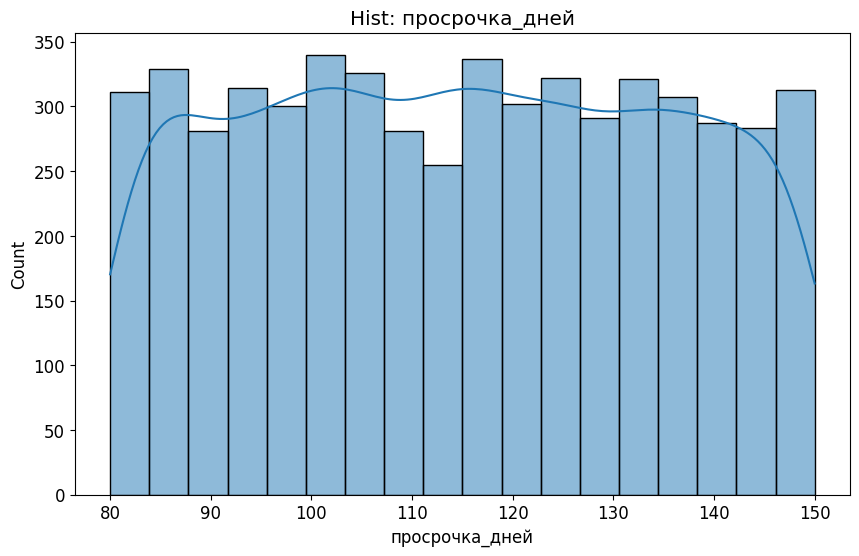

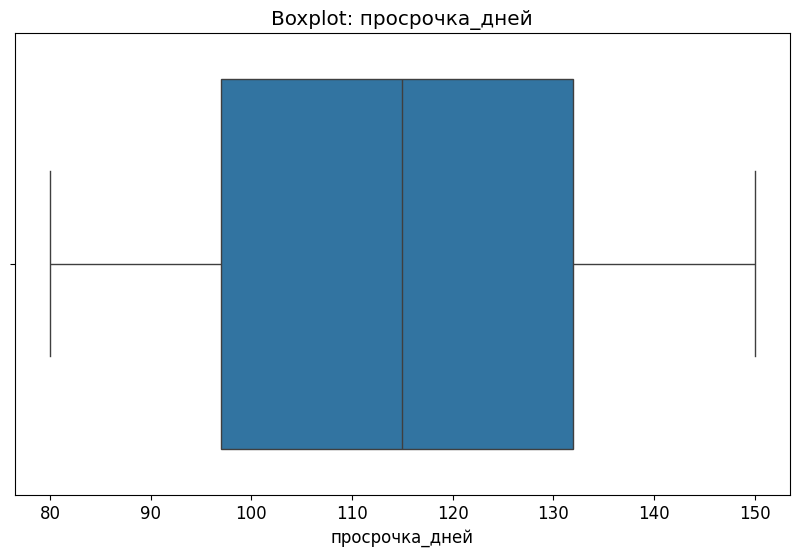

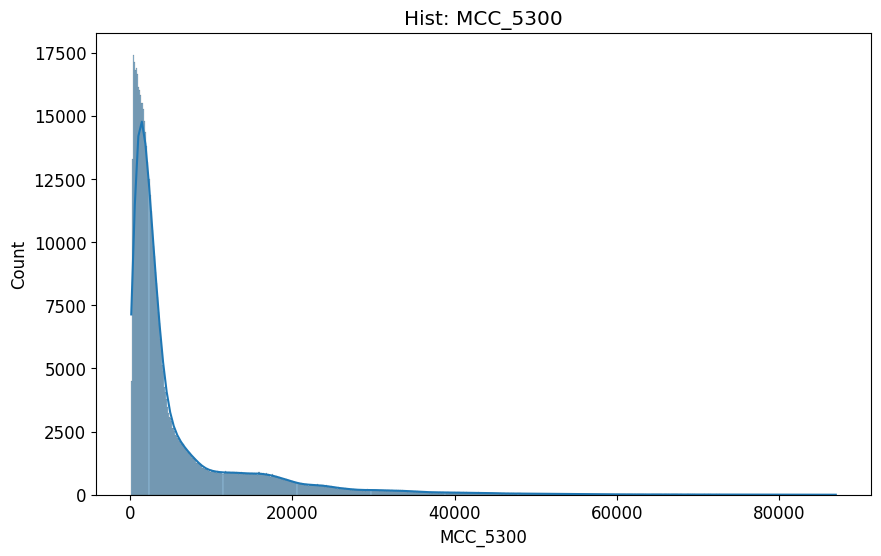

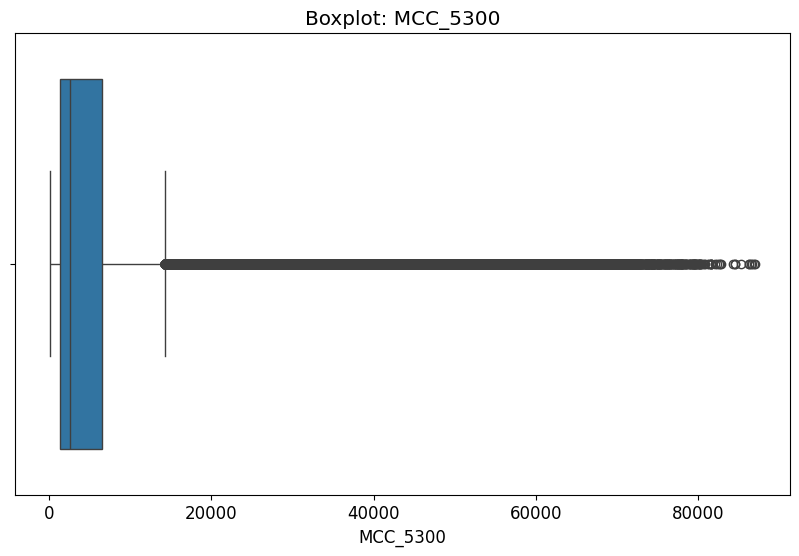

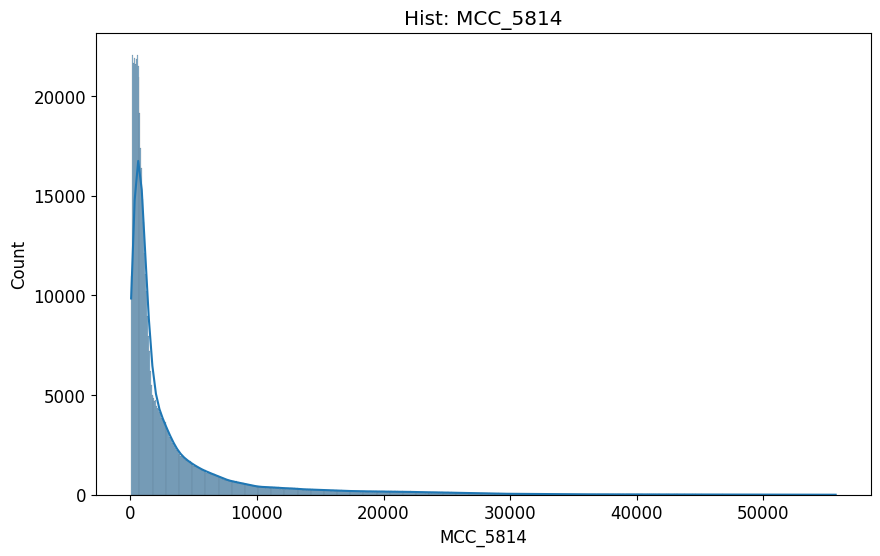

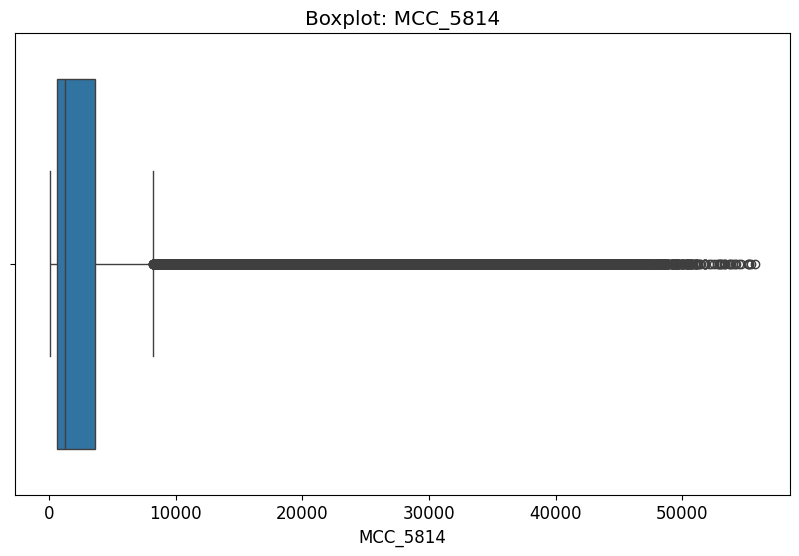

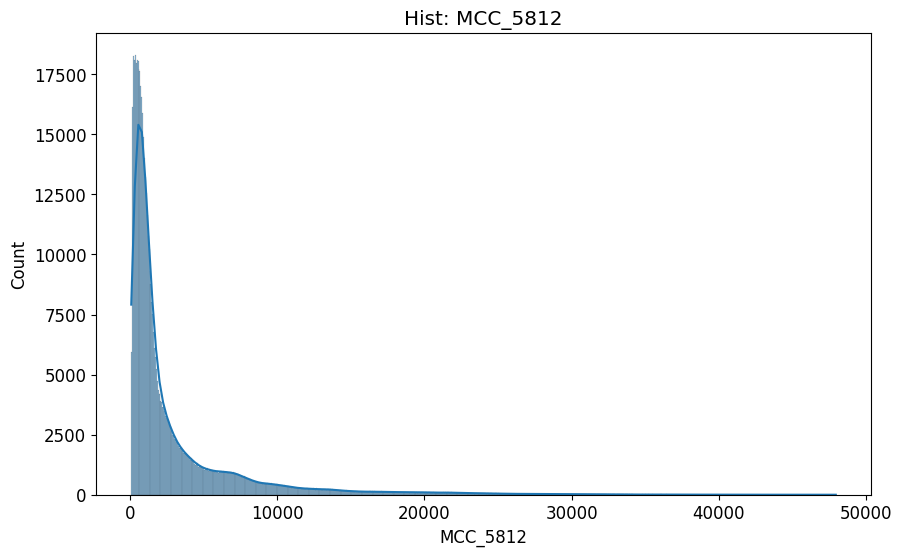

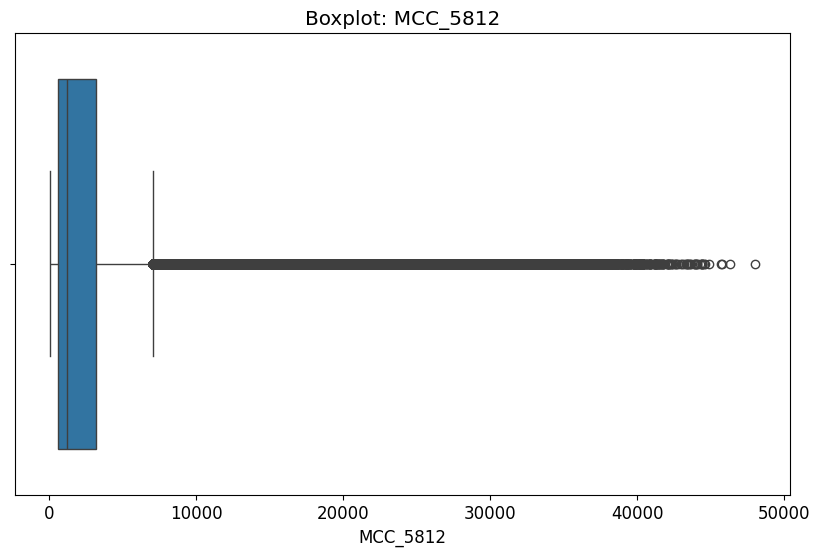

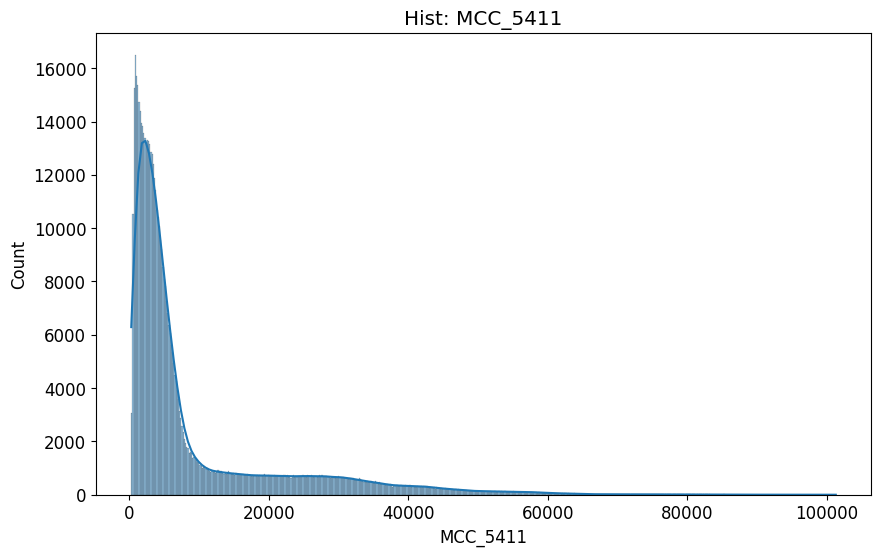

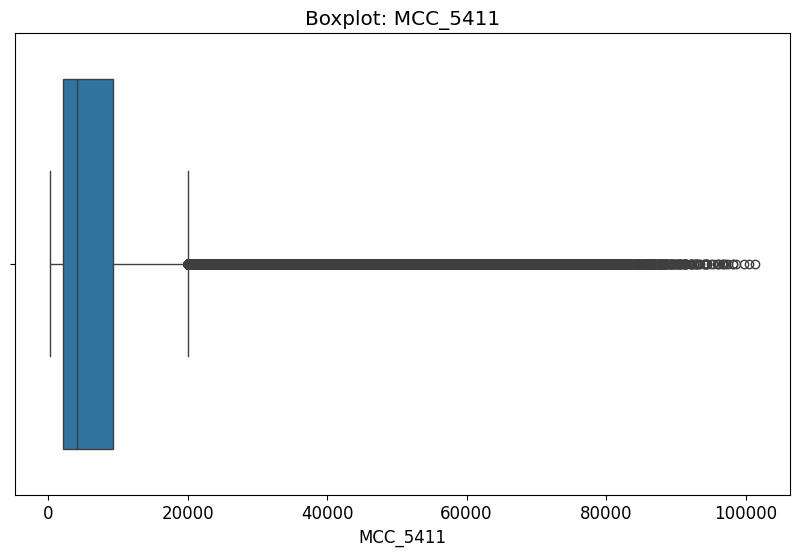

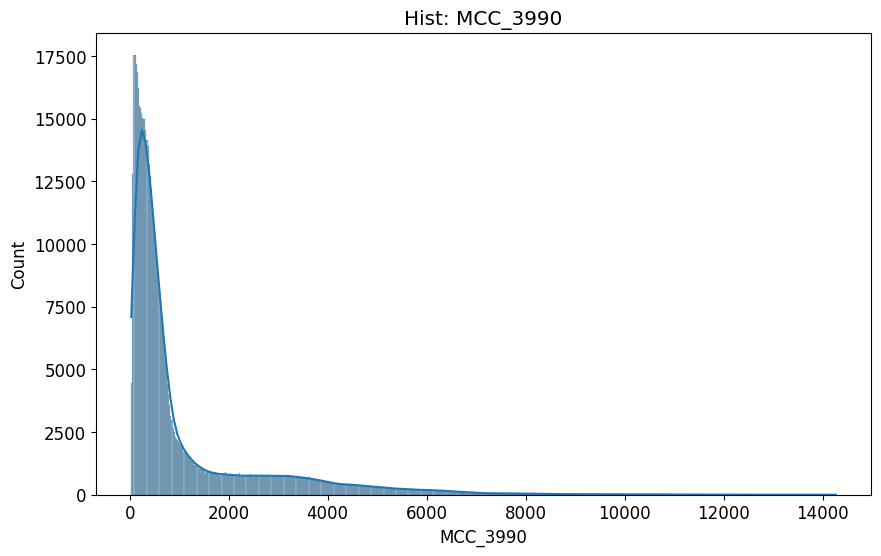

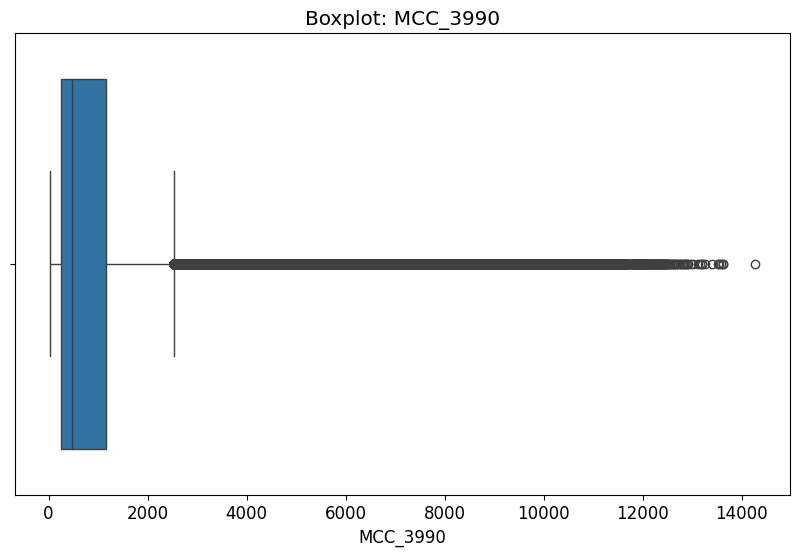

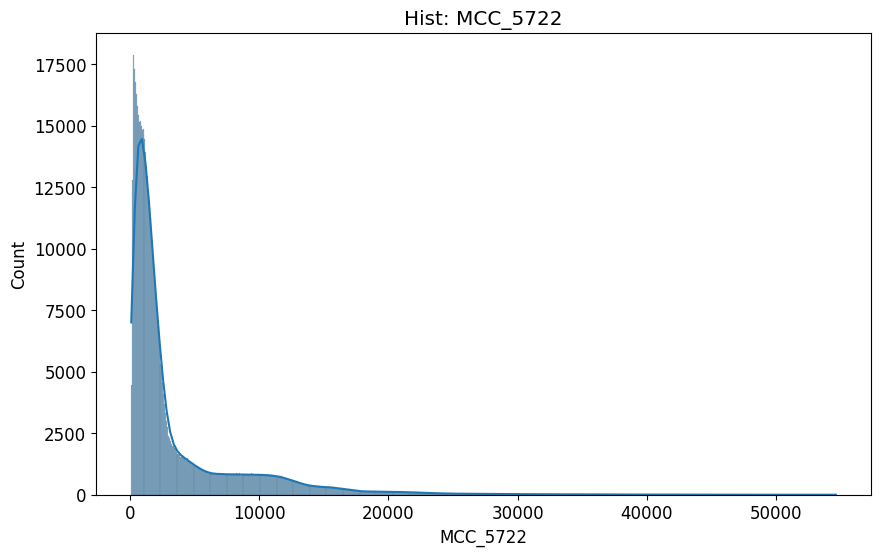

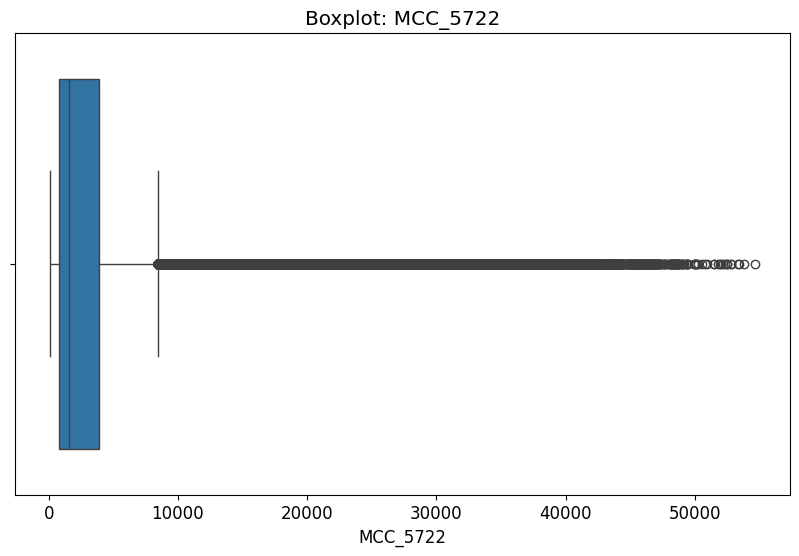

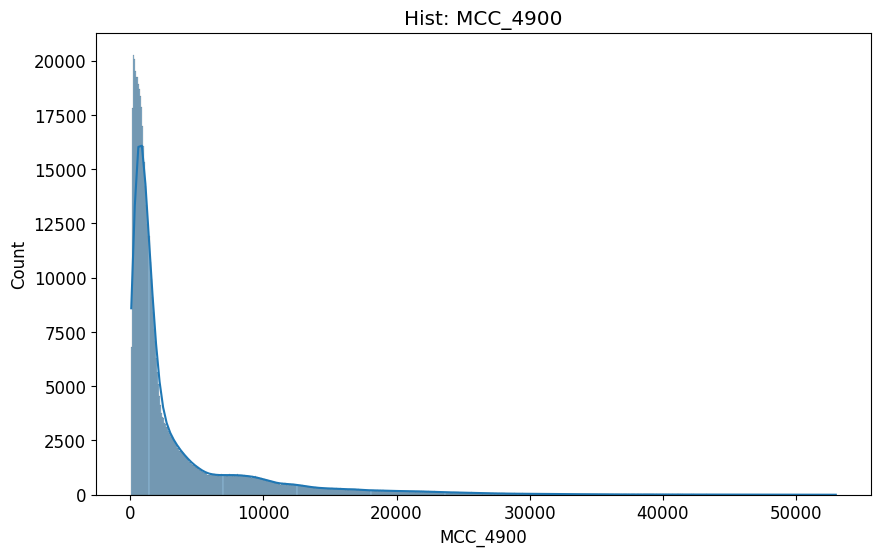

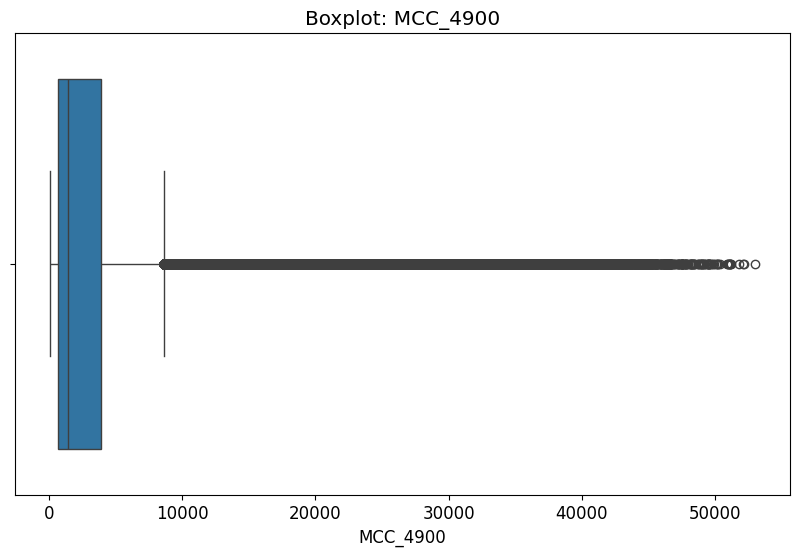

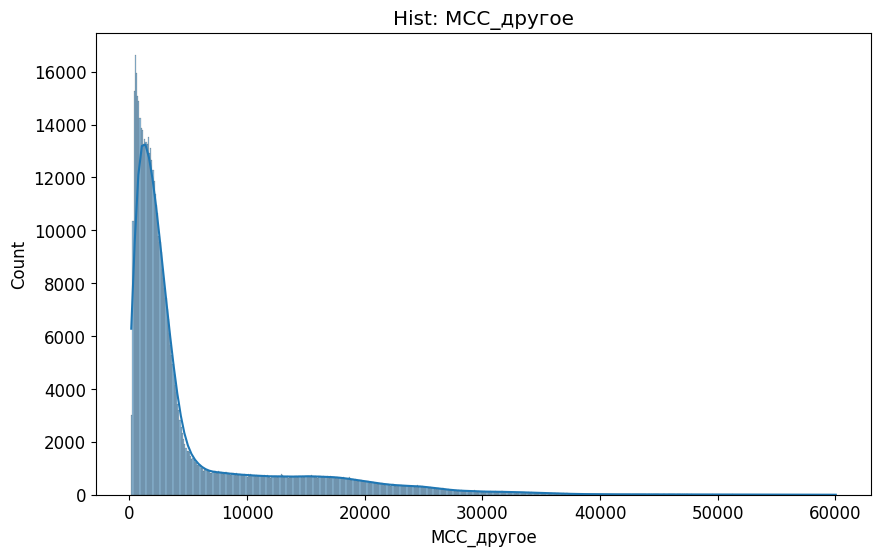

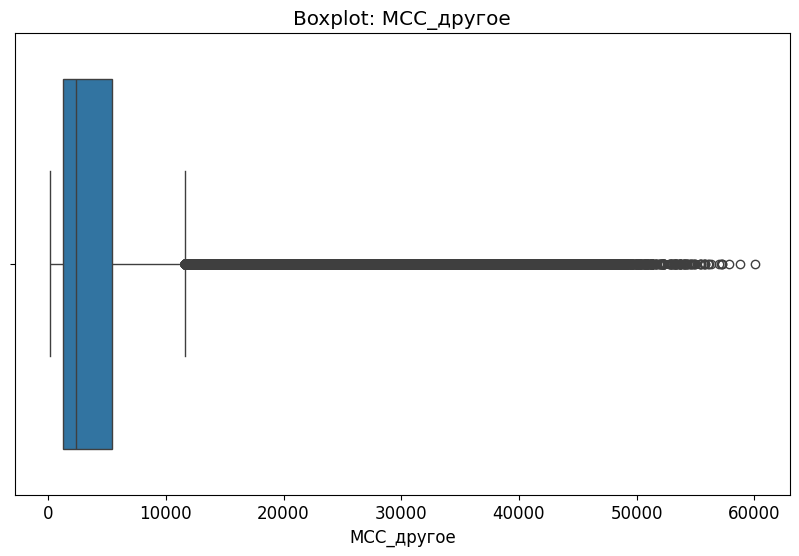

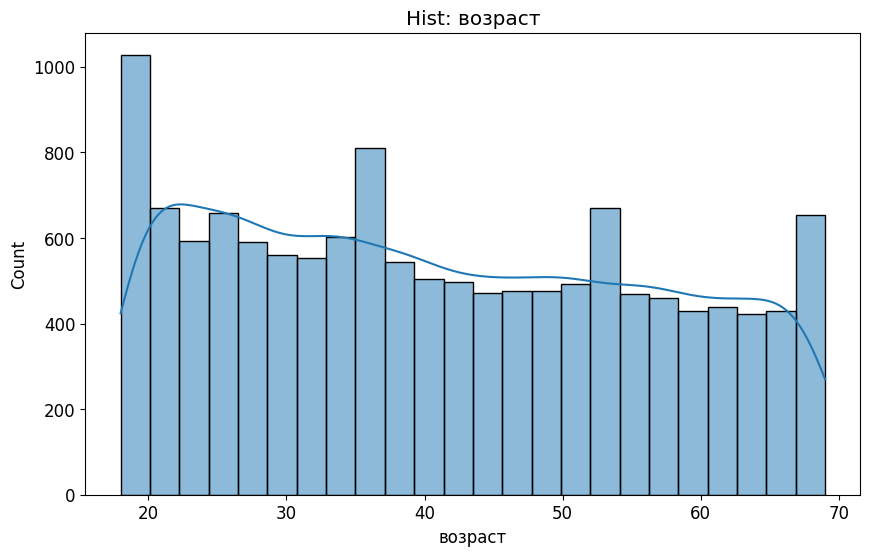

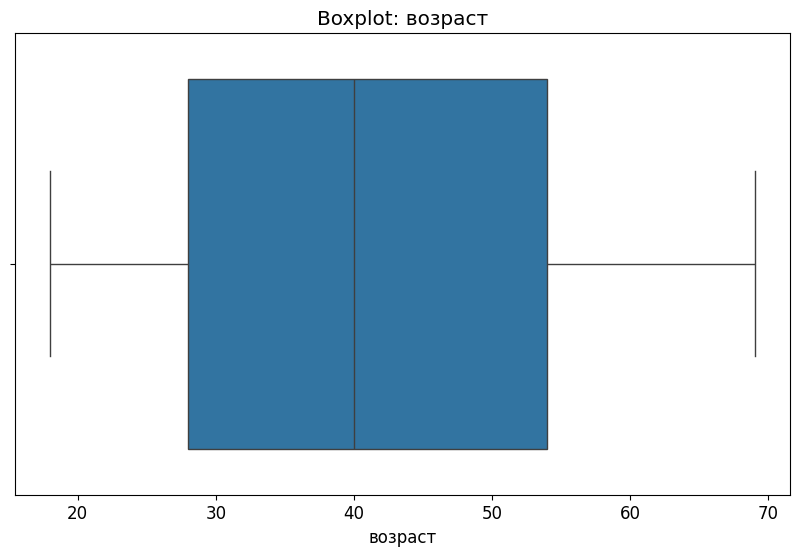

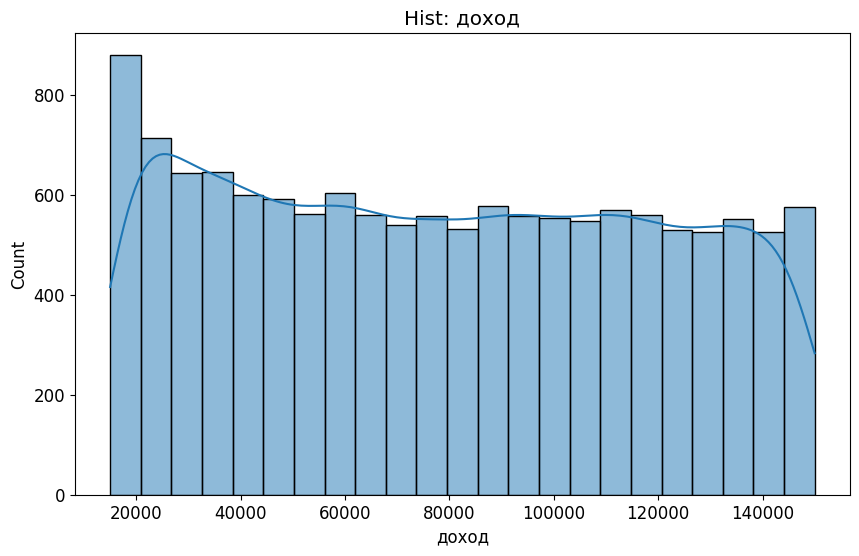

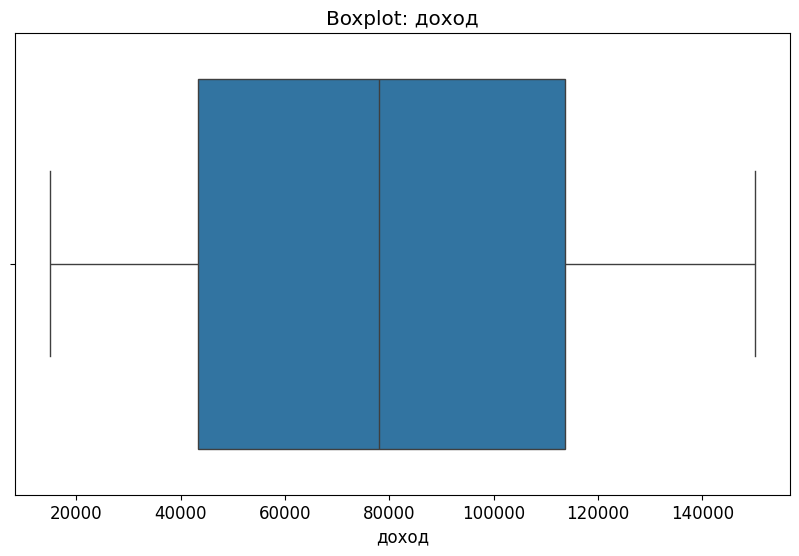

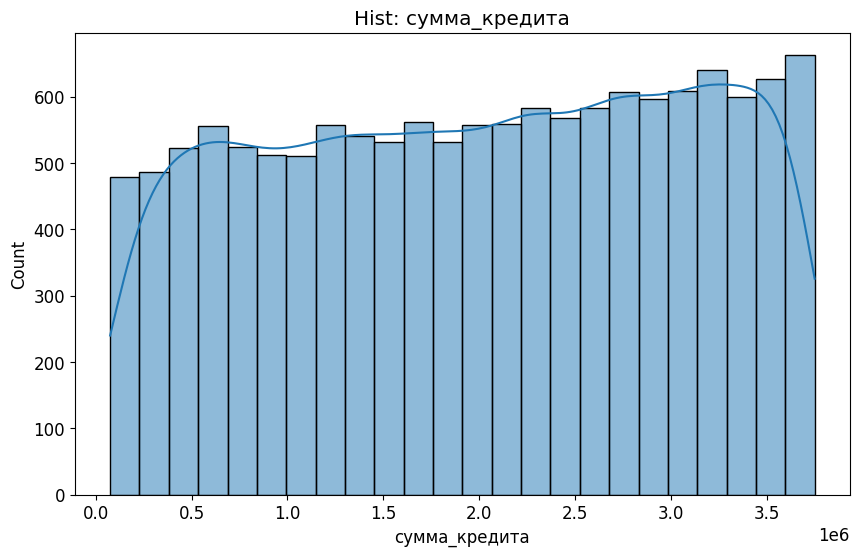

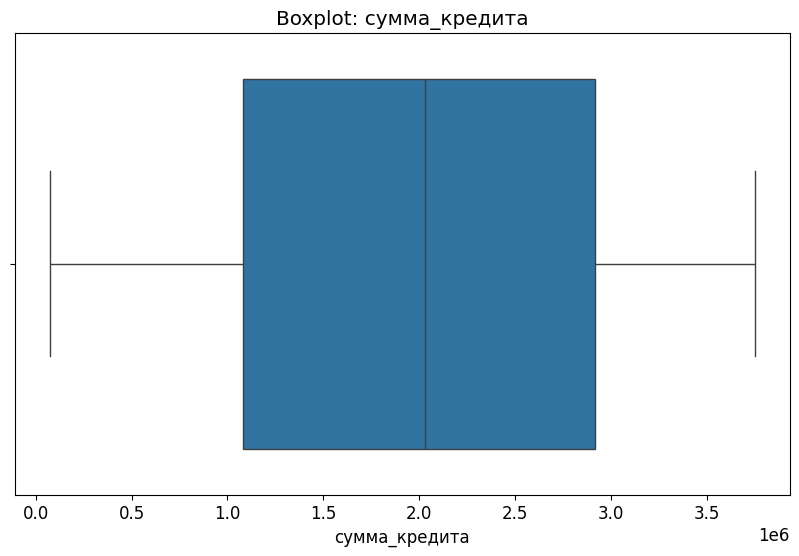

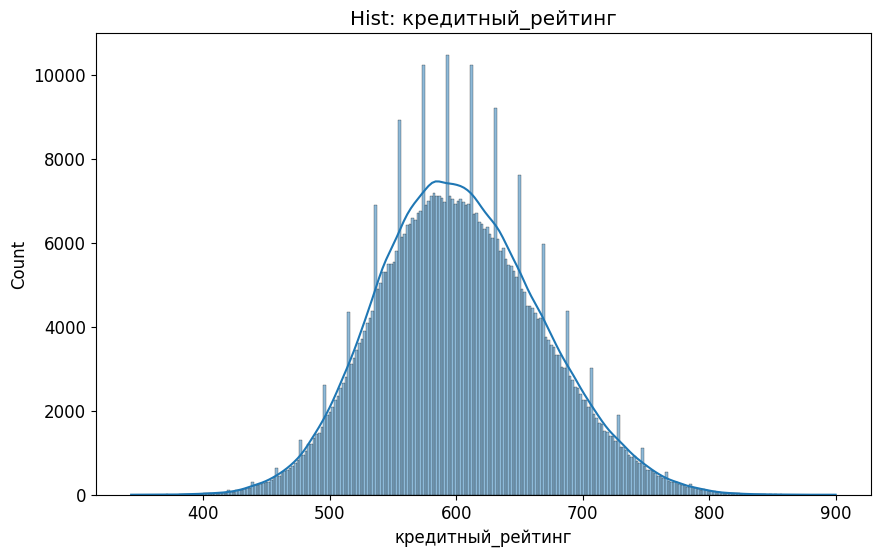

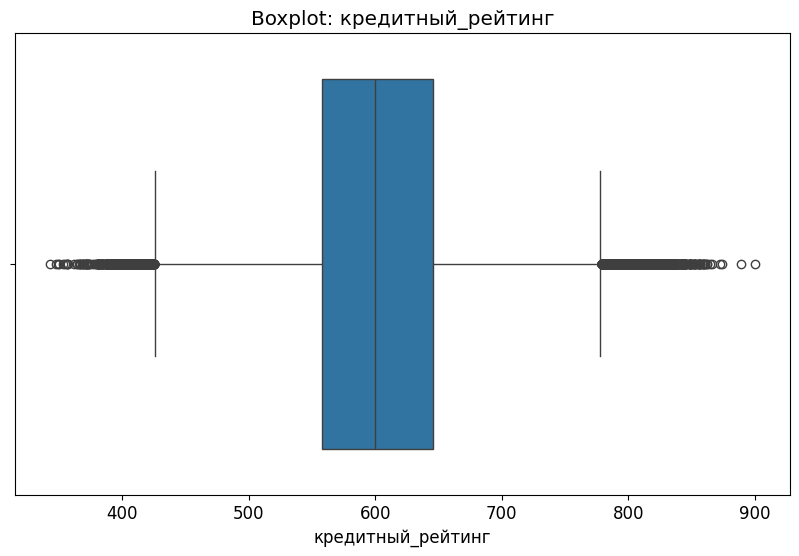

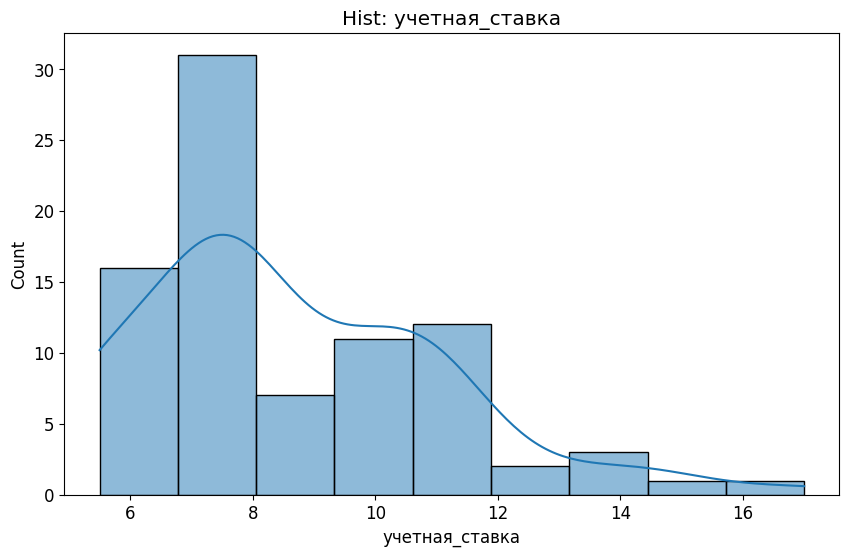

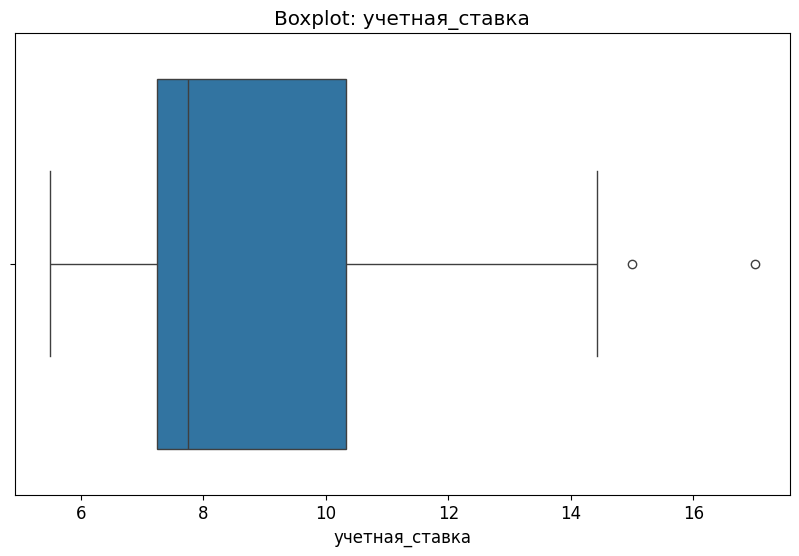

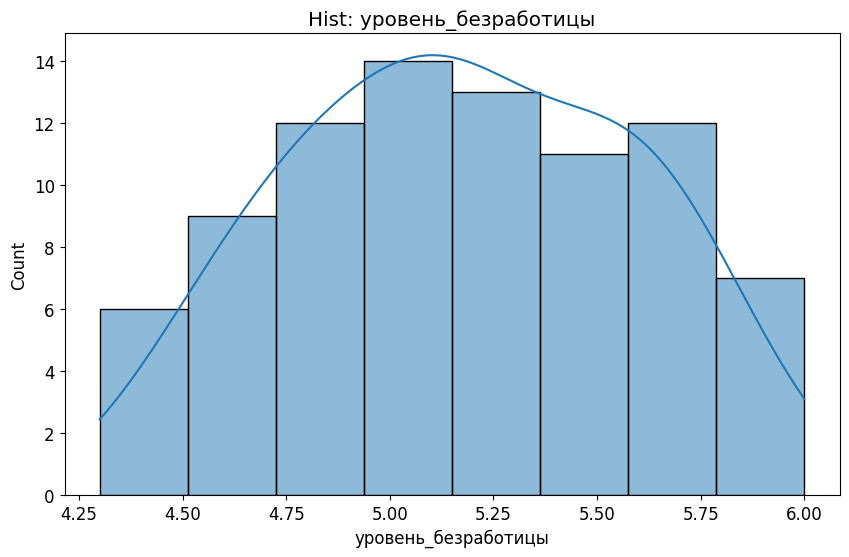

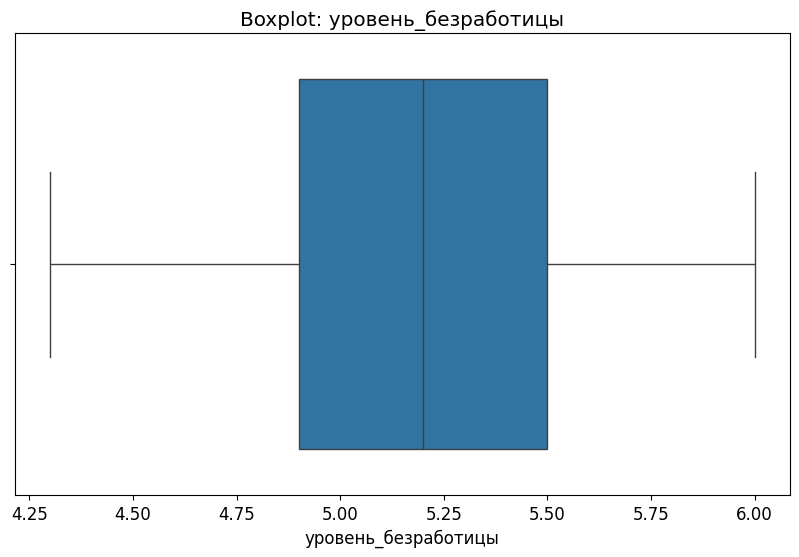

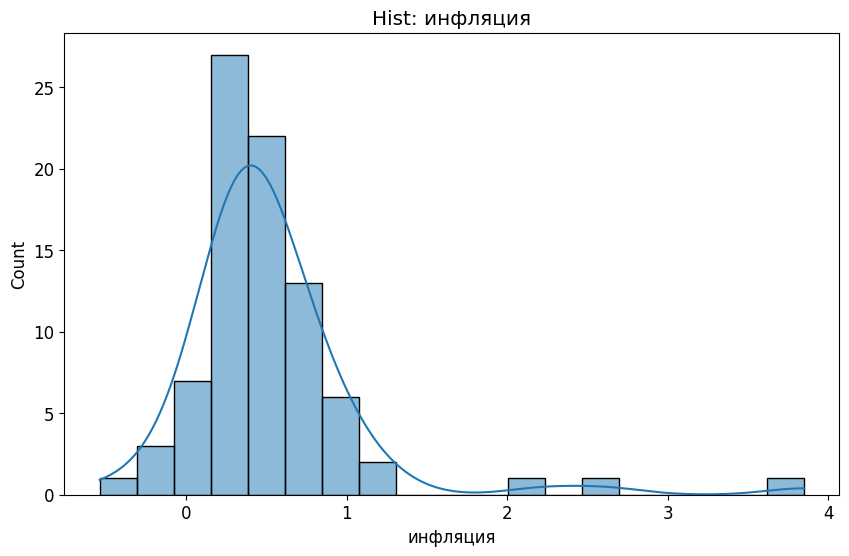

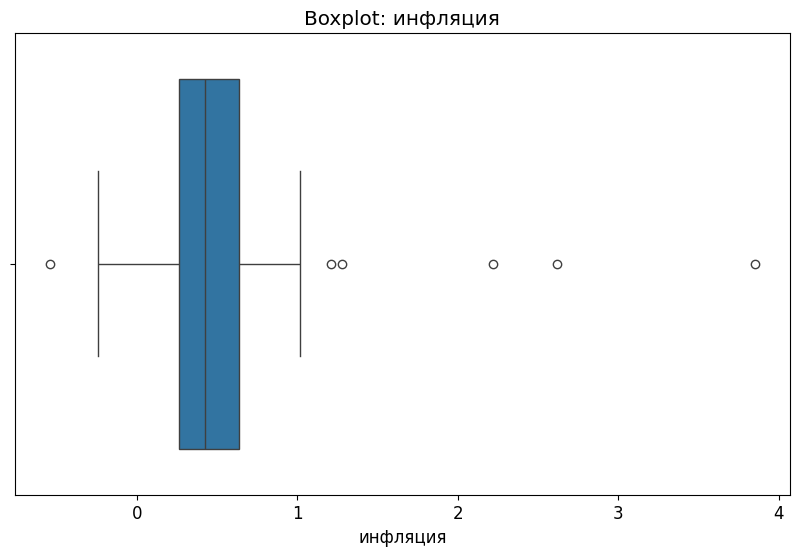

In [142]:
num_cols = ['просрочка_дней', 'MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 
            'MCC_4900', 'MCC_другое', 'возраст', 'доход', 'сумма_кредита', 
            'кредитный_рейтинг', 'учетная_ставка', 'уровень_безработицы', 'инфляция']
for name, df in datasets.items():
    cols = [col for col in num_cols if col in df.columns]
    if cols:
        print("\n\n", name, "\n")
        for col in cols:
            print("Столбец: ", col, "\n")
            data_review(df, col)

<h4>Вывод</h4>
<p>Для признаков расходов по MCC-категориям метод IQR выявляет большое количество выбросов (11–13%). НО эти значения соответствуют особенности финансовых данных, где расходы могут сильно различаться, поскольку экстремальные значения не выглядят аномальными и могут содержать важную информацию о поведении клиентов(не удаляем)

<h3>Корреляции</h3>

In [143]:
def phik_corr_matrix(df, interval_cols=None, drop_cols=None):
    data = df.copy()
    
    if drop_cols:
        data = data.drop(columns=drop_cols, errors='ignore')
    
    corr = data.phik_matrix(interval_cols=interval_cols)
    sns.heatmap(corr, cmap='coolwarm')
    plt.show()
    
    return corr

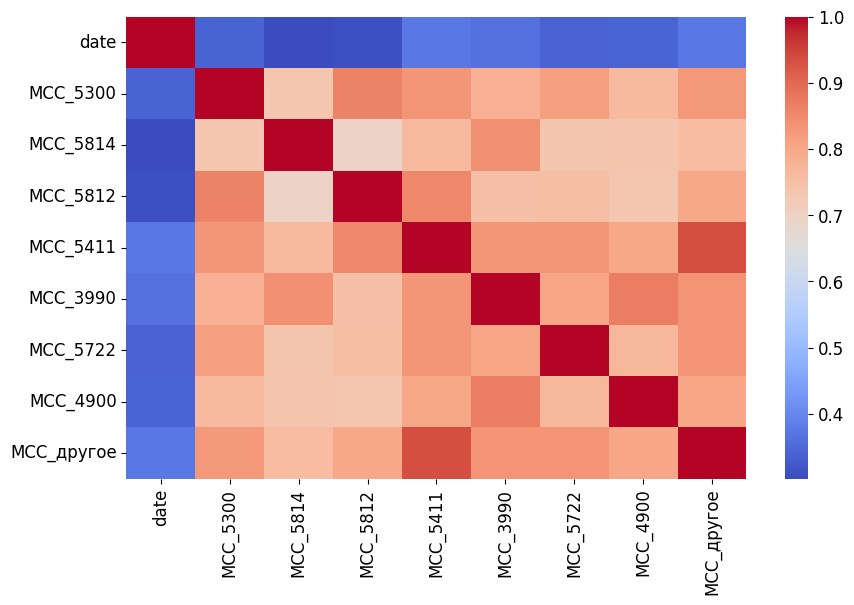

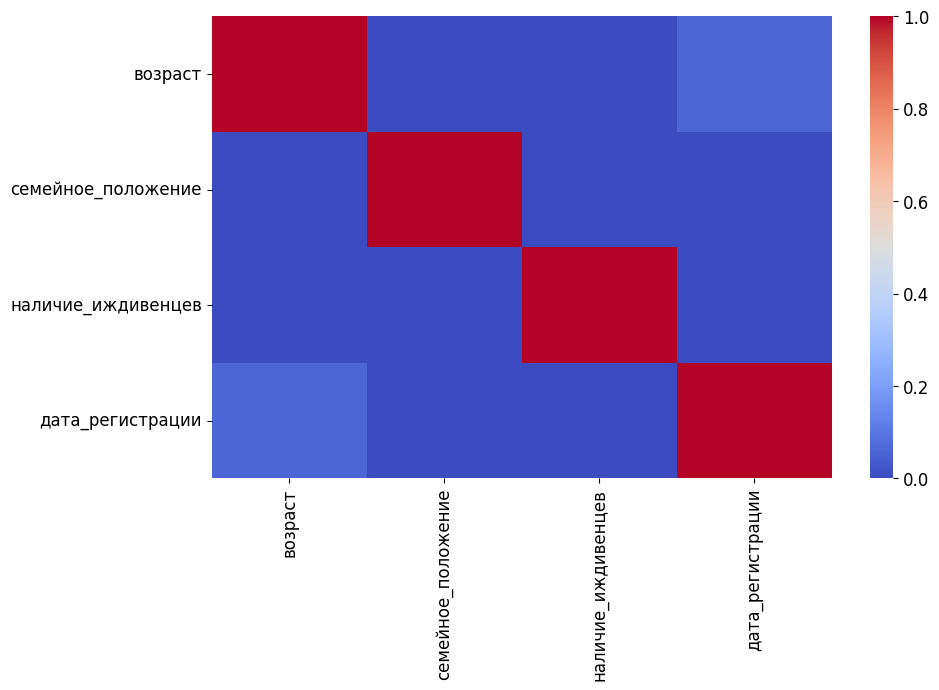

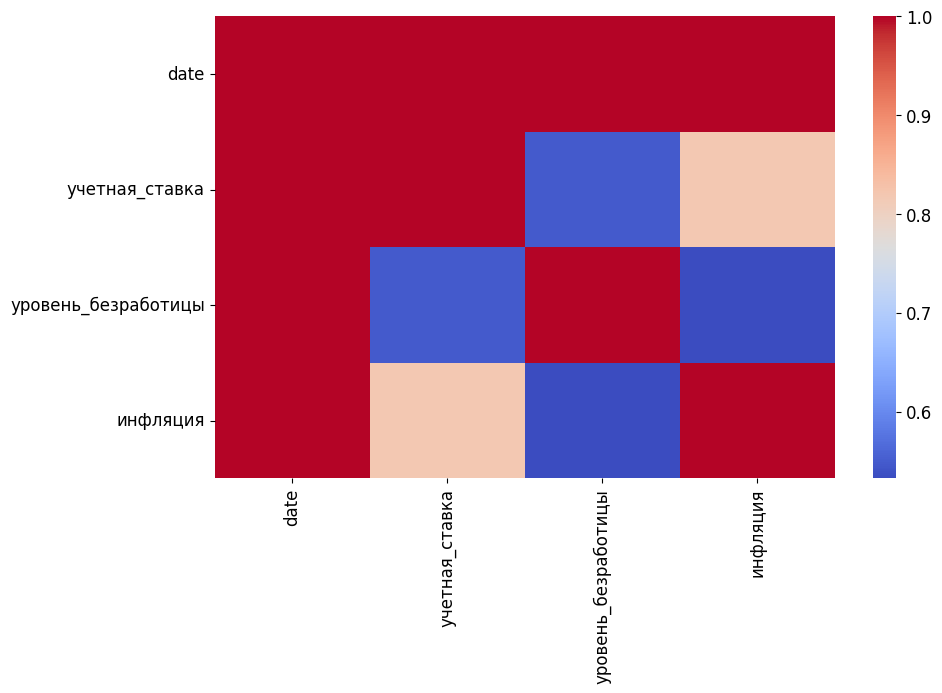

In [144]:
datasets_forphik = {
    'transactions': (transactions, ['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое']),
    'client_description': (client_description, ['возраст', 'наличие_иждивенцев']),
    'macro_data': (macro_data, ['учетная_ставка', 'уровень_безработицы', 'инфляция']),
}

for name, (df, interval_cols) in datasets_forphik.items():
    print(name, "\n")
    phik_corr_matrix(df, interval_cols=interval_cols, drop_cols=["ID"])
    print("\n")

<h4>Вывод по анализу корреляции</h4>

transaction

Между MCC-категориями есть высокая положительная связь (0.73–0.94): клиенты с высокой активностью обычно тратят больше сразу по нескольким категориям. Дата имеет умеренную связь с расходами (0.30–0.38) - изменение поведения клиентов во времени

client_description

Сильных зависимостей нет. Возраст, семейное положение, наличие иждивенцев и дата регистрации практически независимы

macro_data

Макроэкономические показатели умеренно связаны между собой (0.53–0.82). Дата полностью связана с макроэкономическими показателями, поскольку каждому месяцу соответствует набор их значений

Общий вывод

Оснований для удаления признаков по результатам нет

<h2>Этап 3. Объединение данных: собираем все источники данных о клиентах в единую таблицу с учётом временной оси и горизонта прогноза, формируем целевую переменную используя скользящее окно</h2>

<h3>Формирование целевой переменной</h3>
<p>Для каждой пары (клиент, дата) определяем, произойдёт ли просрочка от 90 дней в ближайшие 12 месяцев. Строки, где дефолт случился к моменту скоринга, удаляем</p>

In [145]:
delay['дата_начала_периода'] = pd.to_datetime(delay['дата_начала_периода'])
cohort_grid['score_date'] = pd.to_datetime(cohort_grid['score_date'])

delay['severe'] = (delay['просрочка_дней'] >= 90).astype(int)
last_observation_date = delay["дата_начала_периода"].max()
max_score_date = last_observation_date - pd.Timedelta(days=365)
cohort_grid = cohort_grid[cohort_grid["score_date"] <= max_score_date].copy()

first_default = (
    delay[delay["просрочка_дней"] >= 90]
    .sort_values("дата_начала_периода")
    .groupby("ID", as_index=False)
    .first()[["ID", "дата_начала_периода"]]
    .rename(columns={"дата_начала_периода": "default_date"})
)

final = cohort_grid.merge(first_default, on="ID", how="left")

final["target"] = (final["default_date"].notna()
                   & (final["default_date"] >= final["score_date"])
                   & (final["default_date"] < final["score_date"] + pd.Timedelta(days=365))).astype(int)

final = final[final["default_date"].isna() | (final["default_date"] >= final["score_date"])].copy()

print(final.shape)
print(final['target'].mean())

print(final.shape)
print(final['target'].mean())

<h3>Функция для присоединения признаков </h3>
<p>Функция <code>add_last_known</code> добавляет к каждой строке последний известный срез данных из таблиц транзакции, 
кредитный рейтинг, макроэкономика</p>

In [146]:
def add_last_known(final, monthly_df, date_col):
    m = monthly_df.copy()
    m[date_col] = pd.to_datetime(m[date_col])
    if 'ID' in m.columns:
        merged = final.merge(m, on='ID', how='left')
    else:
        merged = final.merge(m, how='cross')
    group_keys = ['ID', 'score_date']
    merged = merged[merged[date_col] < merged['score_date']]
    idx = merged.groupby(group_keys)[date_col].idxmax()
    result = merged.loc[idx].drop(columns=date_col)

    new_cols = [c for c in result.columns if c not in final.columns]
    result = final.merge(result[group_keys + new_cols], on=group_keys, how='left')

    return result

<h3>Применяем функции к таблицам</h3>
<p>Последовательно присоединяем транзакции, кредитный рейтинг и макроэкономические показатели. После каждого шага проверяем размер таблицы</p>

In [147]:
print(final.shape[0])
final = add_last_known(final, transactions, date_col='date')
print(final.shape[0])
final = add_last_known(final, credit_rating, date_col='date')
print(final.shape[0])
final = add_last_known(final, macro_data, date_col='date')
print(final.shape[0])

final = final.merge(client_description, on='ID', how='left')
final = final.merge(credit_description, on='ID', how='left')
print(final.shape[0])

final = add_last_known(final, mortgage_presence, date_col='дата_открытия')
final['наличие_ипотеки'] = final['наличие_ипотеки'].fillna(0).astype(int)
print(final.shape[0])
print(final['target'].mean())

<h2>Этап 4. Генерация новых признаков: создаём новые признаки на основе имеющихся данных.</h2>

<h3>Признаки по доходу</h3>

In [148]:
mcc_cols = [c for c in final.columns if c.startswith('MCC_')]

final['total_spending'] = final[mcc_cols].sum(axis=1)
final['debt_burden'] = final['total_spending'] / final['доход'].replace(0, np.nan)
final['free_money'] = final['доход'] - final['total_spending']

final['credit_burden'] = final['сумма_кредита'] / final['доход'].replace(0, np.nan)

<h3>Признаки доход, семья</h3>

In [149]:
family_size = final['наличие_иждивенцев'] + (final['семейное_положение'] == 'есть семья').astype(int) + 1
final['per_capita_income'] = final['доход'] / family_size
final['spending_to_credit'] = final['total_spending'] / final['сумма_кредита'].replace(0, np.nan)

<h3>Волатильность траn - агрегат по истории, поэтому считать нужно в таблице transactions до присоединения(add_last_known сам возьмёт значение на нужную дату)</h3>

In [150]:
transactions = transactions.sort_values(['ID', 'date'])
transactions['total_spend_month'] = transactions[mcc_cols].sum(axis=1)

transactions['spend_std_3m'] = (transactions.groupby('ID')['total_spend_month'].transform(lambda s: s.rolling(3, min_periods=2).std()))

spend_std_df = transactions[['ID', 'date', 'spend_std_3m']]
final = add_last_known(final, spend_std_df, date_col='date')
print(final.shape[0])

<h3>Столбец дата регистрации не несет полезной информации лучше использовать его для подсчета "стажа клиента"</h3>

In [151]:
final['дата_регистрации'] = pd.to_datetime(final['дата_регистрации'])
final['experience'] = (final['score_date'] - final['дата_регистрации']).dt.days
final = final.drop(columns='дата_регистрации')

<h3>Дополнительно можно рассмотреть заввисимость количества дефолтов от макроэкономических показателей</h3>

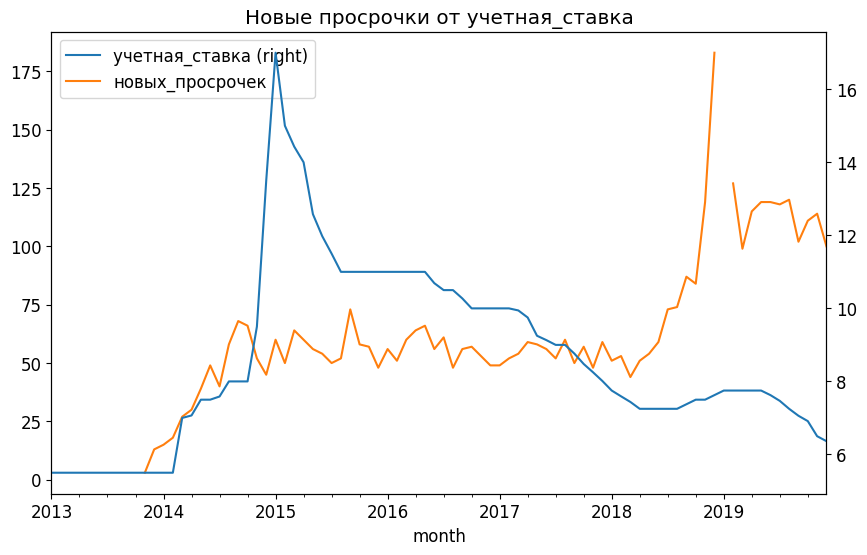

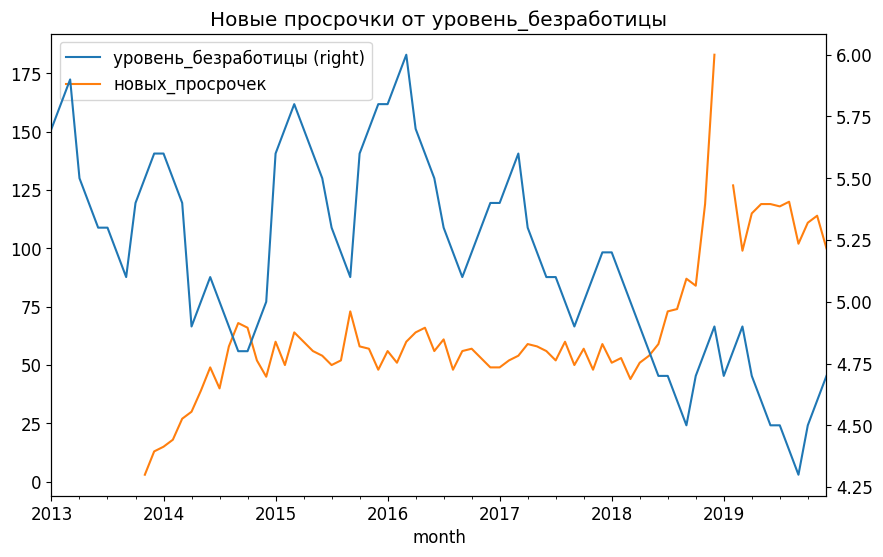

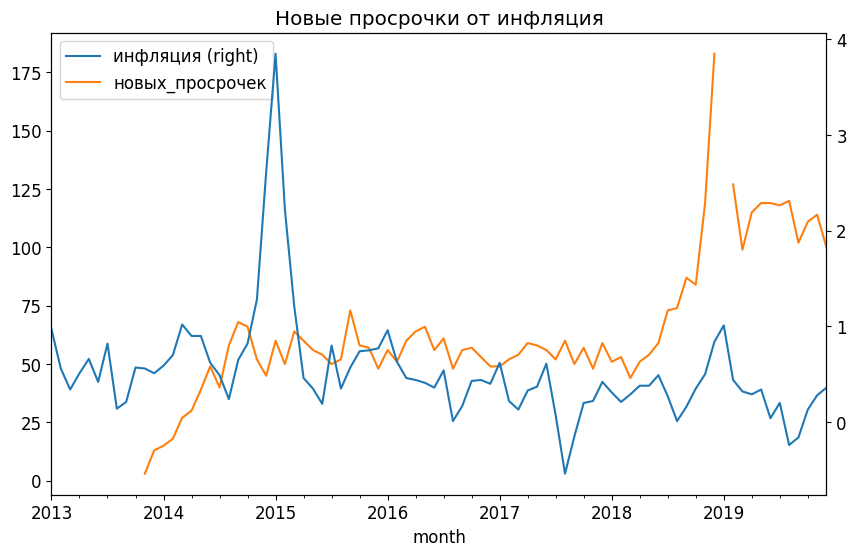

In [152]:
delay_by_month = delay[delay['severe'] == 1].groupby(delay['дата_начала_периода'].dt.to_period('M')).size()

macro_data_m = macro_data.copy()
macro_data_m['date'] = pd.to_datetime(macro_data_m['date'])
macro_data_m['month'] = macro_data_m['date'].dt.to_period('M')

compare = macro_data_m.set_index('month')[['учетная_ставка', 'уровень_безработицы', 'инфляция']]
compare['новых_просрочек'] = delay_by_month

macro_cols = ['учетная_ставка', 'уровень_безработицы', 'инфляция']
for col in macro_cols:
    compare[[col, 'новых_просрочек']].plot(secondary_y=col)
    plt.title(f"Новые просрочки от {col}")
    plt.show()

<h4>Вывод по анализу макроэкономических показателей</h4>

В связи между макропоказателями и новыми просрочками наблюдаются лаги, нет одновременного изменения, реакция проявляется спустя несколько месяцев после изменения рынка, а не сразу.

Сравнивать показатели по одному и тому же месяцу недостаточно. Для оценки нужен расчёт связи между числом новых просрочек и каждым макропоказателем с лагами 1–12 месяцев, чтобы определить момент начала действия эфекта. Это даст более точные результаты, чем сопоставление графиков

<h2>Этап 5. Анализ итоговой таблицы: изучаем распределение целевой переменной, делаем выводы о необходимости балансировки, проверяем итоговую таблицу</h2>

Используем функции объявленные в EDA для анализа итоговой таблицы

In [153]:
datasets_info({'final': final})

In [154]:
def missing_report(df):
    total = len(df)
    for col in df.columns:
        print(col)
        print("\t", "пропусков:", df[col].isna().sum())
        print("\t", f"доля: {round(df[col].isna().sum() / total * 100, 2)}%")
    df_clean = df.dropna()
    print("Без удаления пропусков строк:", len(df))
    print("После удаления:", len(df_clean))
    print("Потеря:", len(df) - len(df_clean))
    print("Доля потерь:", (len(df) - len(df_clean)) / len(df))

missing_report(final)

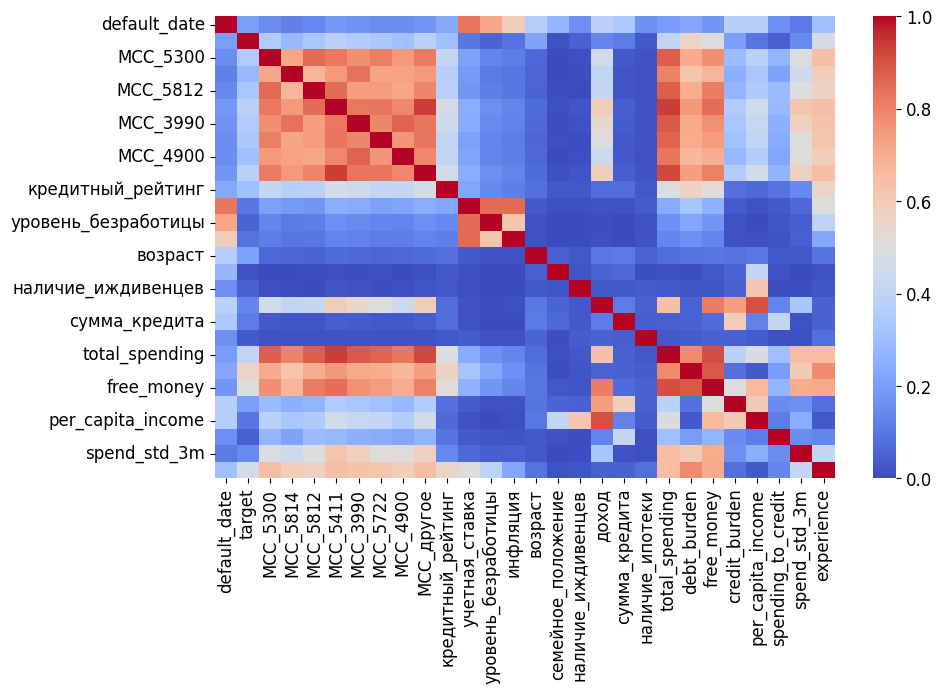

In [155]:
drop_cols = ['ID', 'score_date']
interval_cols = [c for c in final.columns if final[c].dtype in ['int64', 'float64'] and c not in drop_cols + ['target']]

phik_corr_matrix(final, interval_cols=interval_cols, drop_cols=drop_cols)

<h4>Общий вывод по итоговой таблице</h4>
Итоговая таблица - 334696 сторк и 13500 уникальных клиентов, охватывает 72 месяца, 12 месяцев для проверки дефолта по выборке test. Новые признаки: долговая нагрузка, свободные деньги, волатильность 


Строки с пропусками составляют значильную часть данных(85%) из-за столбца default_date
Полное удаление строк с пропусками 285554 строк применим SimpleImputer

Связь признаков с целевой переменной(самые сильные корреляции показывают сгенерированные признаки):

debt_burden (0.58) сильнее всех остальных признаков в таблице
free_money (0.56)
total_spending (0.41) и MCC-категории (0.32–0.42)
кредитный_рейтинг (0.32)
experience (0.46)

Придуманные признаки поведения несут больше информации о риске, чем сырые данные по отдельности 

Слабую связь с таргетом показывают семейное_положение (0.01), наличие_ипотеки (0.04), spending_to_credit (0.05) 

Мультиколлинеарность: total_spending сильно коррелирует почти со всеми MCC-колонками (0.8–0.94), debt_burden, free_money, credit_burden построены из тех же величин и коррелируют друг с другом и с total_spending (0.7–0.9). Для линейной регрессии необходима регуляризация 

Баланс классов. Доля target(1)=13.25% Дисбаланс есть, для базовых моделей нужно сравнивать варианты с class_weight='balanced'. Метрика accuracy малоинформативна<h4>


<h2>Этап 6. Предобработка: делим данные на обучающую, калибровочную и тестовую выборки с учётом временной структуры, кодируем категориальные признаки, собираем пайплайн</h2>

<h3>Проверим временной диапозон итоговой таблицы</h3>

In [156]:
months = sorted(final['score_date'].unique())

print("Количество месяцев:", len(months))
print(months[0])
print(months[-1])

<h3>Разделим данные на 3 периода: последние 12 месяцев тест, предпоследние 12 месяцев калибровка, остальное обучение.</h3>

In [157]:
test_months = months[-12:]
calibration_months = months[-24:-12]
train_months = months[:-24]

print(f"Диапазон train: {train_months[0]} - {train_months[-1]} ({len(train_months)} месяцев)")
print(f"Диапазон calibration: {calibration_months[0]} - {calibration_months[-1]} ({len(calibration_months)} месяцев)")
print(f"Диапазон test: {test_months[0]} - {test_months[-1]} ({len(test_months)} месяцев)")

In [158]:
train = final[final['score_date'].isin(train_months)].copy()
calibration = final[final['score_date'].isin(calibration_months)].copy()
test = final[final['score_date'].isin(test_months)].copy()
train = train.sort_values(['score_date', 'ID']).reset_index(drop=True)
calibration = calibration.sort_values(['score_date', 'ID']).reset_index(drop=True)
test = test.sort_values(['score_date', 'ID']).reset_index(drop=True)

<h4>Отделим целевую переменную во всех периодах </h4>

In [159]:
drop_cols = ['ID', 'score_date', 'target']

X_train = train.drop(columns=drop_cols)
y_train = train['target']

X_cal = calibration.drop(columns=drop_cols)
y_cal = calibration['target']

X_test = test.drop(columns=drop_cols)
y_test = test['target']

<b>X_train, y_train, X_cal, y_cal, X_test, y_test определены</b>

<h3>Объявим препроцессор</h3>

In [160]:
num_cols = ['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 
            'MCC_другое', 'кредитный_рейтинг', 'учетная_ставка', 'уровень_безработицы', 'инфляция', 'возраст', 
            'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки', 'total_spending', 'debt_burden', 'free_money', 
            'credit_burden', 'per_capita_income', 'spending_to_credit', 'spend_std_3m', 'experience']

cat_cols = ['семейное_положение']

In [161]:
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())])

categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', numeric_transformer, num_cols),
                                  ('cat', categorical_transformer, cat_cols)])

<h2>Этап 7. Базовые модели: обучаем логистическую регрессию и случайный лес с кросс-валидацией на трёх фолдах с балансировкой классов и без неё (всего четыре базовых модели)</h2>

In [162]:
def evaluate_model(model, model_name, X, y, groups, cv, scoring):
    cv_results = cross_validate(estimator=model, X=X, y=y, groups=groups, cv=cv, scoring=scoring, n_jobs=-1)
    print(model_name)
    metrics = {'Model': model_name}

    for metric in scoring:
        scores = cv_results[f'test_{metric}']
        metrics[metric] = scores.mean()
        metrics[f'{metric}_std'] = scores.std()

    return model, metrics

In [163]:
def approval_rate_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    total = tn + fp + fn + tp
    return (tn + fn) / total  

def default_rate_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    approved = tn + fn
    return fn / approved if approved > 0 else 0.0  

def missed_defaults_rate_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    actual_positive = fn + tp
    return fn / actual_positive if actual_positive > 0 else 0.0 

In [164]:
gtscv = GroupTimeSeriesSplit(test_size=12, n_splits=3)
groups = train['score_date']
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'approval_rate': make_scorer(approval_rate_score),
    'default_rate': make_scorer(default_rate_score),
    'missed_defaults_rate': make_scorer(missed_defaults_rate_score),
}

logreg_pipeline = Pipeline([('preprocessor', preprocessor),
                            ('model', LogisticRegression(random_state=42, max_iter=1000))])
logreg_model, logreg_metrics = evaluate_model(model=logreg_pipeline, model_name='Logistic Regression', 
                                              X=X_train, y=y_train, groups=groups, cv=gtscv, scoring=scoring)


logreg_balanced_pipeline = Pipeline([('preprocessor', preprocessor),
                                     ('model', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))])
logreg_balanced_model, logreg_balanced_metrics = evaluate_model(model=logreg_balanced_pipeline, model_name='Logistic Regression (balanced)',
                                                                X=X_train, y=y_train, groups=groups, cv=gtscv, scoring=scoring)


rf_pipeline = Pipeline([('preprocessor', preprocessor),
                        ('model', RandomForestClassifier(random_state=42))])
rf_model, rf_metrics = evaluate_model(model=rf_pipeline, model_name='Random Forest', 
                                      X=X_train, y=y_train, groups=groups, cv=gtscv, scoring=scoring)


rf_balanced_pipeline = Pipeline([('preprocessor', preprocessor),
                                 ('model', RandomForestClassifier(random_state=42,class_weight='balanced'))])
rf_balanced_model, rf_balanced_metrics = evaluate_model(model=rf_balanced_pipeline, model_name='Random Forest (balanced)',
                                                        X=X_train, y=y_train, groups=groups, cv=gtscv, scoring=scoring)

In [165]:
metrics_df = pd.DataFrame([logreg_metrics, logreg_balanced_metrics, rf_metrics, rf_balanced_metrics]).set_index('Model')

metrics_df

In [166]:
rf_oversampled_pipeline = ImbPipeline([('preprocessor', preprocessor),
                                       ('sampler', RandomOverSampler(random_state=42)),
                                       ('model', RandomForestClassifier(random_state=42))])
rf_oversampled_model, rf_oversampled_metrics = evaluate_model(model=rf_oversampled_pipeline, model_name='Random Forest(RandomOverSampler)',
                                                              X=X_train, y=y_train, groups=groups, cv=gtscv, scoring=scoring)

rf_undersampled_pipeline = ImbPipeline([('preprocessor', preprocessor),
                                        ('sampler', RandomUnderSampler(random_state=42)),
                                        ('model', RandomForestClassifier(random_state=42))])
rf_undersampled_model, rf_undersampled_metrics = evaluate_model(model=rf_undersampled_pipeline, model_name='Random Forest(RandomUnderSampler)',
                                                                X=X_train, y=y_train, groups=groups, cv=gtscv, scoring=scoring)

rf_smote_pipeline = ImbPipeline([('preprocessor', preprocessor),
                                 ('sampler', SMOTE(random_state=42)),
                                 ('model', RandomForestClassifier(random_state=42))])
rf_smote_model, rf_smote_metrics = evaluate_model(model=rf_smote_pipeline, model_name='Random Forest (SMOTE)',
                                                  X=X_train, y=y_train, groups=groups, cv=gtscv, scoring=scoring)

rf_soft_weight_pipeline = Pipeline([('preprocessor', preprocessor),
                                    ('model', RandomForestClassifier(random_state=42, class_weight={0: 1, 1: 3}))])
rf_soft_weight_model, rf_soft_weight_metrics = evaluate_model(model=rf_soft_weight_pipeline, model_name='Random Forest (class_weight 1:3)',
                                                              X=X_train, y=y_train, groups=groups, cv=gtscv, scoring=scoring)

In [167]:
balancing_comparison_df = pd.DataFrame([rf_balanced_metrics,
                                        rf_oversampled_metrics,
                                        rf_undersampled_metrics,
                                        rf_smote_metrics,
                                        rf_soft_weight_metrics]).set_index('Model')

balancing_comparison_df.round(4)

<h3>Вывод</h3>
Логистическая регрессия: высокий ROC-AUC 0.8767, низкий recall 0.19(модель пропускает 81% дефолтов - missed defaults rate), approval rate завышен 95.3%, default rate 10.5%
При балансировке классов recall вырос 0.78, missed defaults rate упал 22%, default rate упал 3.8%, approval rate 72.8%, ROC-AUC почти не меняется. Балансировка сдвигает порог и делает более осторожные решения

Random Forest: ROC-AUC 0.9172 и precision 0.63, но recall 0.34 модель пропускает 66% дефолтов и default rate 8.8%
Сбалансированный Random Forest: лучший среди всех четырёх моделей ROC-AUC 0.9196 (максимум), F1 0.54, recall 0.53, precision 0.55. Missed defaults rate падает 47%, default rate 6.6%, approval rate 88.1%

Требованиям approval rate ≥65%, default rate ≤2%, missed defaults rate ≤4% не соответствует пока что ни одна модель: все метрики посчитаны при пороге по умолчанию, а не при пороге, подобранном под ограничения. Random Forest (balanced) - лучшая пара по ROC-AUC и F1 c наибольшей объясняющей способностью, для этой модели можно будет снижать missed defaults rate за счёт approval rate, сохраняя надёжную модель.

Random Forest превосходит Logistic Regression по ROC-AUC и F1, значит в данных есть нелинейные зависимости, которые линейная модель не улавливает
Балансировка классов необходима для обеих моделей: без неё recall и missed defaults rate неприемлемы для решения

В качестве основной модели для дальнейшего подбора гиперпараметров (Optuna), калибровки и поиска порога выбираем Random Forest (с балансировкой классов) как модель с лучшим ROC-AUC и наибольшим потенциалом

<h2>Этап 8. Гиперпараметры: Подбираем гиперпараметры используя Optuna</h2>

In [168]:
def objective(trial):
    params = {'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=50),
              'max_depth': trial.suggest_int('max_depth', 6, 16),
              'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
              'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
              'max_features': trial.suggest_categorical('max_features', ['sqrt', 0.5]),}

    model = Pipeline([('preprocessor', preprocessor),
                      ('model', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1, **params))])

    scores = cross_val_score(estimator=model, X=X_train, y=y_train, groups=groups, cv=gtscv,
                             scoring=make_scorer(missed_defaults_rate_score), n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(study.best_value)
print('Лучшие параметры:', study.best_params)

In [180]:
best_rf_params = {'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 7,'max_features': 'sqrt',}

best_pipeline_cv = Pipeline([('preprocessor', preprocessor),
                             ('model', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1, **best_rf_params))])

skip, rf_tuned_metrics = evaluate_model(model=best_pipeline_cv, model_name='Random Forest(tuned)', X=X_train, y=y_train, groups=groups, cv=gtscv, scoring=scoring)

metrics_df = pd.concat([metrics_df, pd.DataFrame([rf_tuned_metrics]).set_index('Model')])
metrics_df.round(4)

<h3>Вывод</h3>
Подбор гиперпараметров Random Forest через Optuna (5 параметров, 20 испытаний, оптимизация по missed defaults rate) нашёл модель с max_depth=6, min_samples_split=9, min_samples_leaf=7, n_estimators=200, max_features='sqrt', которая снизила missed defaults rate с 0.470 до 0.073, но это произошло за счёт снижения остальных метрик: ROC-AUC упал с 0.9196 до 0.8941, approval rate с 0.8814 до 0.6527. Оптимизация по одной метрике без учёта остальных сделала модель осторожной она помечает больше клиентов как рискованных, жертвуя одобрениями ради снижения пропусков дефолтов
Random Forest (balanced), Random Forest (tuned) окончательный выбор будет на этапе калибровки и подбора порога

<h2>Этап 9. Калибровка и подбор порога: калибруем лучшую модель, строим график калибровки, подбираем порог классификации под требования: approval rate ≥ 65%, default rate ≤ 2%, missed defaults rate ≤ 4%</h2>

In [181]:
rf_balanced_pipeline.fit(X_train, y_train)
best_pipeline_cv.fit(X_train, y_train)
calibration_months_sorted = sorted(calibration['score_date'].unique())
calib_fit_months = calibration_months_sorted[:6]
calib_eval_months = calibration_months_sorted[6:]

calib_fit = calibration[calibration['score_date'].isin(calib_fit_months)].copy()
calib_eval = calibration[calibration['score_date'].isin(calib_eval_months)].copy()

drop_cols = ['ID', 'score_date', 'target']
X_calib_fit = calib_fit.drop(columns=drop_cols)
y_calib_fit = calib_fit['target']
X_calib_eval = calib_eval.drop(columns=drop_cols)
y_calib_eval = calib_eval['target']

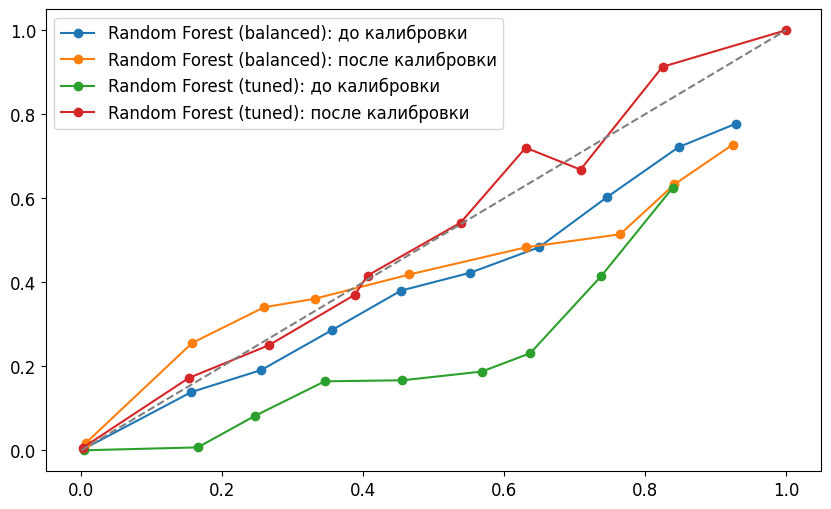

In [182]:
def transform_without_model(pipeline, X):
    return pipeline.named_steps["preprocessor"].transform(X)

def plot_calibration(y_true, y_prob, label):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=label)

def calibrate_and_evaluate(pipeline, model_name, X_cal, y_cal, X_test, y_test):
    X_cal_prepared = transform_without_model(pipeline, X_cal)
    X_test_prepared = transform_without_model(pipeline, X_test)

    calibrated_model = CalibratedClassifierCV(FrozenEstimator(pipeline.named_steps["model"]), method="isotonic")
    calibrated_model.fit(X_cal_prepared, y_cal)

    y_proba_base = pipeline.predict_proba(X_test)[:, 1]
    y_proba = calibrated_model.predict_proba(X_test_prepared)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    print(model_name)
    print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")
    print(f"Brier: {brier_score_loss(y_test, y_proba):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1: {f1_score(y_test, y_pred):.4f}")
    print()

    plot_calibration(y_test, y_proba_base, f"{model_name}: до калибровки")
    plot_calibration(y_test, y_proba, f"{model_name}: после калибровки")

    return calibrated_model, y_proba


calibrated_rf_balanced, y_proba_balanced = calibrate_and_evaluate(
    rf_balanced_pipeline, "Random Forest (balanced)", X_calib_fit, y_calib_fit, X_calib_eval, y_calib_eval
)
calibrated_rf_tuned, y_proba_tuned = calibrate_and_evaluate(
    best_pipeline_cv, "Random Forest (tuned)", X_calib_fit, y_calib_fit, X_calib_eval, y_calib_eval
)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.legend()
plt.show()

<h3>Вывод</h3>

До калибровки Random Forest (balanced) в основном занижал вероятности смещение в одну сторону

Random Forest (tuned) предсказывает вероятности сильно ниже кривой проблема в нестабильности из-за структуры дерева

После калибровки обе кривые приблизились к диагонали идеальной калибровки особенно tuned модель. Метрика Brier score около 0.06 - оченнь хорошее качество предсказанний: модель проверяет, чтобы вероятности были близки к реальным 

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

In [186]:
X_calib_eval_prepared_balanced = transform_without_model(rf_balanced_pipeline, X_calib_eval)
X_calib_eval_prepared_tuned = transform_without_model(best_pipeline_cv, X_calib_eval)
y_proba_balanced_eval = calibrated_rf_balanced.predict_proba(X_calib_eval_prepared_balanced)[:, 1]
y_proba_tuned_eval = calibrated_rf_tuned.predict_proba(X_calib_eval_prepared_tuned)[:, 1]

def find_best_threshold(y_true, y_proba, model_name):
    thresholds = np.array([i / 100 for i in range(1, 100)])
    results = []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        results.append({'threshold': t,
                        'recall': recall_score(y_true, y_pred_t),
                        'precision': precision_score(y_true, y_pred_t),
                        'approval_rate': approval_rate_score(y_true, y_pred_t),
                        'default_rate': default_rate_score(y_true, y_pred_t),
                        'missed_defaults_rate': missed_defaults_rate_score(y_true, y_pred_t),})
        
    results_df = pd.DataFrame(results)
    valid = results_df[(results_df['approval_rate'] >= 0.65) &
                       (results_df['default_rate'] <= 0.02) &
                       (results_df['missed_defaults_rate'] <= 0.04)]
    return results_df, valid

results_balanced, valid_balanced = find_best_threshold(y_calib_eval, y_proba_balanced_eval, 'Random Forest (balanced)')
results_tuned, valid_tuned = find_best_threshold(y_calib_eval, y_proba_tuned_eval, 'Random Forest (tuned)')

In [187]:
valid_balanced.sort_values('approval_rate', ascending=False)

In [188]:
valid_tuned.sort_values('approval_rate', ascending=False).head(10)

<h3> Вывод</h3>
Для выбора финального порога рассмотрим лучшие варианты обеих моделей: Random Forest (balanced) при threshold=0.04 даёт approval_rate 0.689, но Random Forest (tuned) при том же threshold=0.04 даёт более сильное сочетание характеристик: default_rate ниже примерно в 1.5 раза (0.0018 против 0.0027) и соответственно missed_defaults_rate ниже примерно в 1.5 раза (0.0123 против 0.0186), при небольшой потере approval_rate (0.671 против 0.689).
Преимущество tuned модели связано с её гиперпараметрами. Они на предыдущем этапе подбирались через Optuna с оптимизацией missed defaults rate, а balanced модель использовалась с параметрами по умолчанию без учёта бизнес-метрик, поэтому tuned даёт лучшую совокупность метрик, сохраняя допустимый уровень approval_rate
В качестве финального порога для модели Random Forest (tuned) threshold=0.04.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

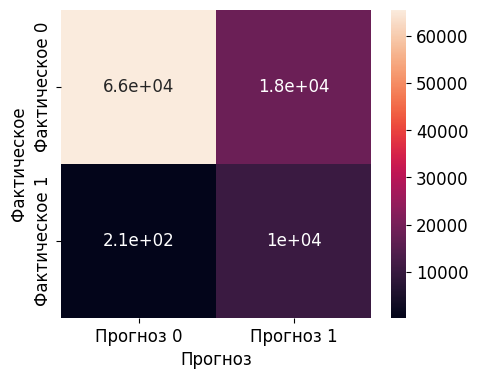

In [189]:
final_pipeline_for_transform = best_pipeline_cv      
final_calibrated_model = calibrated_rf_tuned         
final_threshold = 0.04                         

X_test_prepared = transform_without_model(final_pipeline_for_transform, X_test)
y_proba_test = final_calibrated_model.predict_proba(X_test_prepared)[:, 1]
y_pred_test = (y_proba_test >= final_threshold).astype(int)

print("ROC-AUC", round(roc_auc_score(y_test, y_proba_test), 4))
print("PR-AUC", round(average_precision_score(y_test, y_proba_test), 4))
print("Brier score", round(brier_score_loss(y_test, y_proba_test), 4))
print("Precision", round(precision_score(y_test, y_pred_test), 4))
print("Recall", round(recall_score(y_test, y_pred_test), 4))
print("F1", round(f1_score(y_test, y_pred_test), 4))

print("Approval rate", round(approval_rate_score(y_test, y_pred_test), 4))
print("Default rate", round(default_rate_score(y_test, y_pred_test), 4))
print("Missed defaults rate", round(missed_defaults_rate_score(y_test, y_pred_test), 4))

cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['Фактическое 0', 'Фактическое 1'],columns=['Прогноз 0', 'Прогноз 1'])
print(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True)
plt.ylabel('Фактическое')
plt.xlabel('Прогноз')
plt.show()

<h3>Вывод по итоговой модели</h3>
<p>Модель: Random Forest(tuned) - <code>max_depth=6, min_samples_split=9, min_samples_leaf=7, n_estimators=200, max_features='sqrt'</code>, вариант с оптимизацией missed_defaults_rate, откалибрована с помощью isotonic</p>
<p>Порог классификации: 0.04</p>
<p>Метрики на тестовой выборке:</p>
<ul>
  <li>ROC-AUC: 0.9153</li>
  <li>PR-AUC: 0.4948</li>
  <li>Brier: 0.0697</li>
  <li>Precision: 0.3593</li>
  <li>Recall: 0.9795</li>
  <li>F1: 0.5257</li>
  <li>Approval rate: 0.6979</li>
  <li>Default rate: 0.0033</li>
  <li>Missed defaults rate: 0.0205</li>
</ul>
<h4>Вывод</h4>
<ul>
  <li>Рост метрик на тесте связан c выборкой: 10447 положительных объектов на 94295 наблюдений (11%), что ниже среднего (13.26%)</li>
  <li>Низкий precision (0.36) результат оптимизации missed_defaults_rate через Optuna: модель уменьшает precision увеличивая recall, помечая надёжных клиентов как рискованных</li>
  <li>approval rate 0.6979 ≥ 0.65, default rate 0.0033 ≤ 0.02, missed defaults rate 0.0205 ≤ 0.04</li>
  <li>Запас по default rate по-прежнему большой, можно сместить порог и повысить approval rate, увеличив дефолты, но и увеличив число удачно выданных кредитов. Запас по missed defaults rate уже не такой значительный (0.0205 против лимита 0.04), поэтому сдвигать порог стоит с осторожностью - следует узнать препочтение заказчика</li>   
</ul>

<h2>Этап 11. Отчёт: фиксируем итоговые параметры модели, оцениваем важность признаков (feature_importances_), формулируем выводы и рекомендации по дальнейшей работе модели</h2>

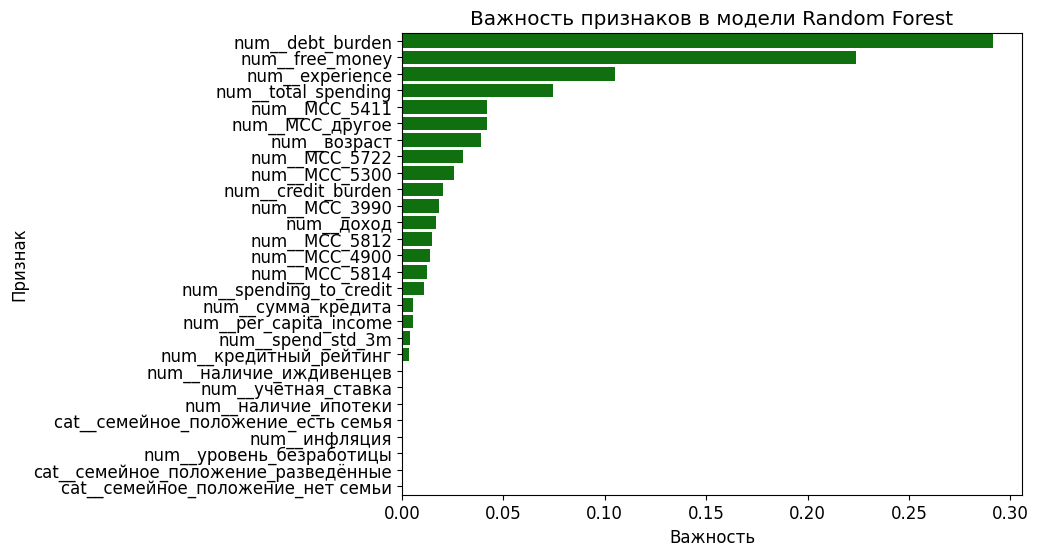

In [190]:
best_model = best_pipeline_cv.named_steps['model']
feature_names = best_pipeline_cv.named_steps['preprocessor'].get_feature_names_out()

importances = best_model.feature_importances_
feature_importances = pd.DataFrame({'feature': feature_names,
                                    'importance': importances})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
print(feature_importances )
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importances, x='importance', y='feature', color='green')
plt.title('Важность признаков в модели Random Forest')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.show()

<h4>Вывод по важности признаков</h4>
<ul>
  <li>Наиболее значимые признаки сгенерированные вручную: debt_burden(0.298) и free_money(0.217). Для задачи кредитного скоринга: не доход или траты по отдельности, а соотношение трат к доходу и свободные деньги определяют способность клиента</li>
  <li>experience(0.101) стаж клиента в банке (разница между датой скоринга и датой регистрации) третий по значимости. Более старые клиенты банка ведут себя предсказуемее, или сам стаж показывает надёжность</li>
  <li>total_spending (0.085) и MCC-категории дают ощутимый вклад</li>
  <li>Макроэкономические показатели и демографические признаки почти не влияют на решение модели, она ориентируется на финансовые данные клиента, а не на экономические данные или личные данные.</li>
</ul>

<h3>Выводы по проекту</h3>

<h4>1. Цель и задачи исследования</h4>
<p>Цель - разработать модель поведенческого скоринга, которая выявляет клиентов с риском просрочки от 90 дней, чтобы банк мог эффективнее управлять резервами, ликвидностью и снижать риск дефолтов. Задача - бинарная классификация с временной структурой: целевая переменная строится скользящим окном на 12 месяцев вперёд для каждой пары клиент-месяц.</p>

<h4>2. Подготовка данных и выборок</h4>
<p>Объединено 8 источников данных (транзакции, кредитный рейтинг, макроэкономика, описание клиента и кредита, ипотека) в единую таблицу из 334696 наблюдений по 11613 клиентам за 72 месяца. Пропусков и дубликатов, требующих отдельной обработки, почти не выявлено, выбросы в MCC-категориях признаны особенностью финансовых данных и сохранены. Данные разделены по времени на train (48 месяцев), calibration (12 месяцев) и test (12 месяцев)</p>

<h4>3. Поиск и настройка модели</h4>
<p>Сравнены логистическая регрессия и случайный лес с балансировкой классов и без неё (4 базовые модели), а также разные методы борьбы с дисбалансом (class_weight, RandomOverSampler, RandomUnderSampler, SMOTE). Random Forest с балансировкой показал лучший ROC-AUC (0.9196) и F1 (0.5413) среди базовых вариантов. Дальнейший подбор гиперпараметров через Optuna (20 испытаний, оптимизация под missed_defaults_rate) дал параметры max_depth=6, min_samples_split=9, min_samples_leaf=7, n_estimators=200, max_features='sqrt', которая снизила пропуск дефолтов ценой снижения approval rate и ROC-AUC</p>

<h4>4. Калибровка вероятностей</h4>
<p>Обе модели (balanced и tuned) откалиброваны isotonic-регрессией на отдельной выборке. До калибровки Random Forest (balanced) занижал вероятности, а tuned-модель также сильно занижала предсказания. После калибровки обе кривые приблизились к идеальной диагонали, Brier score на calib_eval снизился до уровня 0.0638 у tuned-модели</p>

<h4>5. Оптимизация бизнес-порога</h4>
<p>На calibration-выборке подобран порог 0.04 для tuned-модели - надёжное сочетание default rate (0.0018) и missed defaults rate (0.0123) при approval rate 0.671, удовлетворяющее всем трём ограничениям (approval rate ≥ 65%, default rate ≤ 2%, missed defaults rate ≤ 4%) с заметным запасом.</p>

<h4>6. Анализ важности признаков</h4>
<p>Наиболее значимые признаки сгенерированные вручную, а не сырые: debt_burden (0.291) и free_money (0.224) в сумме дают больше половины суммарной важности модели, 3 и 4 место experience стаж клиента в банке (0.105) и total_spending (0.074). Макроэкономические показатели и демографические признаки (семейное положение, наличие иждивенцев, наличие ипотеки) практически не влияют на решение модели</p>

<h4>7. Финальный пайплайн</h4>
<p>Итоговая модель Random Forest (tuned), откалиброванный isotonic-регрессией, с порогом 0.04. На тестовой выборке: ROC-AUC 0.9153, PR-AUC 0.4948, Brier 0.0697, Precision 0.3593, Recall 0.9795, F1 0.5257, Approval rate 0.6979, Default rate 0.0033, Missed defaults rate 0.0205. Все три бизнес-требования выполнены с запасом. Низкий precision ради минимизации пропущенных дефолтов на этапе подбора гиперпараметров.</p>

<h4>8. Основные выводы и рекомендации для бизнеса</h4>
<ul>
  <li>Модель полностью соответствует всем трём бизнес-требованиям и может быть внедрена в текущем виде для скоринга клиентов.</li>
  <li>Запас по default rate (0.0033 << 0.02) большой, а по missed defaults rate (0.0205 при пороге 0.04) более низкий: порог можно сдвинуть, чтобы увеличить approval rate и объём выдач кредитов, но решившись на рост дефолтов, выбор определяться приоритетами заказчика.</li>
  <li>Наибольшую предсказательную ценность несут не сырые данные о доходе или тратах, а признаки нагрузки и свободных денег это стоит учитывать при развитии модели, отдавая приоритет генерации связанных признаков доход/траты </li>
  <li>Макроэкономические показатели почти не используются моделью требуются доработки: добавление лаговых макропризнаков (с задержкой 1–12 месяцев)</li>
  <li>Требуется проверить стабильность модели и изменять порог при изменение ситуации.</li>
</ul>